In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
def load_all_files(file_dir='/mnt/user-data/uploads'):
    """Load all 4 CTCF hopping TSV files"""
    file_names = [
        'ctcf_<<_hopping.tsv',
        'ctcf_<>_hopping.tsv',
        'ctcf_><_hopping.tsv',
        'ctcf_>>_hopping.tsv'
    ]
    
    dfs = {}
    for file_name in file_names:
        file_path = Path(file_dir) / file_name
        if file_path.exists():
            print(f"Loading {file_name}...")
            df = pd.read_csv(file_path, sep='\t')
            # Extract orientation from filename
            orientation = file_name.replace('ctcf_', '').replace('_hopping.tsv', '')
            dfs[orientation] = df
            print(f"  Loaded {len(df)} rows")
        else:
            print(f"Warning: {file_name} not found at {file_path}")
    
    return dfs

In [3]:
def calculate_control_averages(dfs):
    """Calculate average insulation and dot scores for control conditions"""
    controls = {}
    
    for orientation, df in dfs.items():
        print(f"\n{'='*60}")
        print(f"Controls for orientation: {orientation}")
        print(f"{'='*60}")
        
        # Control 1: NO_CTCF
        no_ctcf = df[df['configuration'] == 'CONTROL_NO_CTCF']
        if len(no_ctcf) > 0:
            avg_insulation_no_ctcf = no_ctcf['avg_insulation'].mean()
            avg_dot_no_ctcf = no_ctcf['avg_outer_dot_score'].mean()
            print(f"\nCONTROL_NO_CTCF:")
            print(f"  N = {len(no_ctcf)}")
            print(f"  Avg Insulation: {avg_insulation_no_ctcf:.6f}")
            print(f"  Avg Outer Dot Score: {avg_dot_no_ctcf:.6f}")
            
            controls[f'{orientation}_NO_CTCF'] = {
                'avg_insulation': avg_insulation_no_ctcf,
                'avg_outer_dot_score': avg_dot_no_ctcf,
                'n': len(no_ctcf)
            }
        
        # Control 2: OUTER_ONLY
        outer_only_config = f'CONTROL_OUTER_ONLY_{orientation}'
        outer_only = df[df['configuration'] == outer_only_config]
        if len(outer_only) > 0:
            avg_insulation_outer = outer_only['avg_insulation'].mean()
            avg_dot_outer = outer_only['avg_outer_dot_score'].mean()
            print(f"\n{outer_only_config}:")
            print(f"  N = {len(outer_only)}")
            print(f"  Avg Insulation: {avg_insulation_outer:.6f}")
            print(f"  Avg Outer Dot Score: {avg_dot_outer:.6f}")
            
            controls[f'{orientation}_OUTER_ONLY'] = {
                'avg_insulation': avg_insulation_outer,
                'avg_outer_dot_score': avg_dot_outer,
                'n': len(outer_only)
            }
    
    return controls

In [4]:
def classify_middle_orientation(ctcf_orientations_str, num_middle_ctcfs):
    """Classify the middle CTCF orientations as convergent or mixed"""
    if num_middle_ctcfs == 0:
        return 'none'
    
    try:
        # Parse the string representation of the list
        import ast
        orientations = ast.literal_eval(ctcf_orientations_str)
        
        if len(orientations) < 2:
            return 'none'
        
        # Extract middle CTCFs (exclude first and last which are outer)
        middle_orients = orientations[1:-1]
        
        if len(middle_orients) == 0:
            return 'none'
        
        # Check if all middle CTCFs have the same orientation
        if len(set(middle_orients)) == 1:
            return 'convergent'
        else:
            return 'mixed'
    except:
        return 'unknown'


In [5]:
def prepare_plotting_data(dfs):
    """Prepare data for plotting by extracting non-control configurations"""
    plotting_data = []
    
    for orientation, df in dfs.items():
        # Filter out controls
        non_controls = df[~df['configuration'].str.contains('CONTROL', na=False)]
        
        for _, row in non_controls.iterrows():
            middle_type = classify_middle_orientation(row['ctcf_orientations'], row['num_middle_ctcfs'])
            
            plotting_data.append({
                'orientation': orientation,
                'num_ctcfs': row['num_ctcfs'],
                'num_middle_ctcfs': row['num_middle_ctcfs'],
                'configuration': row['configuration'],
                'middle_orientation_type': middle_type,
                'avg_insulation': row['avg_insulation'],
                'avg_outer_dot_score': row['avg_outer_dot_score']
            })
    
    return pd.DataFrame(plotting_data)

In [6]:
def plot_insulation_by_num_ctcfs(plot_df, controls, output_file='insulation_by_num_middle_ctcfs.png'):
    """Plot average insulation for different numbers of middle CTCFs across orientations"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    orientations = ['<<', '<>', '><', '>>']
    colors = sns.color_palette("husl", len(orientations))
    
    for idx, orientation in enumerate(orientations):
        if orientation not in plot_df['orientation'].values:
            continue
        
        # Filter data for this outer orientation
        orient_data = plot_df[plot_df['orientation'] == orientation]
        
        # Plot convergent (solid line)
        convergent_data = orient_data[orient_data['middle_orientation_type'] == 'convergent']
        if len(convergent_data) > 0:
            grouped = convergent_data.groupby('num_middle_ctcfs')['avg_insulation'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            
            ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2.5, markersize=8,
                       label=f'{orientation} convergent', color=colors[idx], 
                       linestyle='-', capsize=5, capthick=2)
        
        # Plot mixed (dashed line)
        mixed_data = orient_data[orient_data['middle_orientation_type'] == 'mixed']
        if len(mixed_data) > 0:
            grouped = mixed_data.groupby('num_middle_ctcfs')['avg_insulation'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            
            ax.errorbar(x, y, yerr=yerr, marker='s', linewidth=2.5, markersize=8,
                       label=f'{orientation} mixed', color=colors[idx], 
                       linestyle='--', capsize=5, capthick=2)
    
    # Add control lines
    for key, values in controls.items():
        if 'NO_CTCF' in key:
            orientation = key.split('_')[0]
            ax.axhline(y=values['avg_insulation'], linestyle=':', alpha=0.4, linewidth=1.5,
                      label=f'{orientation} No CTCF', color='gray')
    
    ax.set_xlabel('Number of Middle CTCFs', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Insulation', fontsize=14, fontweight='bold')
    ax.set_title('Average Insulation vs Number of Middle CTCFs\nby Outer Orientation and Middle Configuration', 
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # print(f"\nSaved plot: {output_file}")
    plt.show()

In [7]:
def plot_dot_score_by_num_ctcfs(plot_df, controls, output_file='dot_score_by_num_middle_ctcfs.png'):
    """Plot average outer dot score for different numbers of middle CTCFs across orientations"""
    fig, ax = plt.subplots(figsize=(14, 8))
    
    orientations = ['<<', '<>', '><', '>>']
    colors = sns.color_palette("husl", len(orientations))
    
    for idx, orientation in enumerate(orientations):
        if orientation not in plot_df['orientation'].values:
            continue
        
        # Filter data for this outer orientation
        orient_data = plot_df[plot_df['orientation'] == orientation]
        
        # Plot convergent (solid line)
        convergent_data = orient_data[orient_data['middle_orientation_type'] == 'convergent']
        if len(convergent_data) > 0:
            grouped = convergent_data.groupby('num_middle_ctcfs')['avg_outer_dot_score'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            
            ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2.5, markersize=8,
                       label=f'{orientation} convergent', color=colors[idx], 
                       linestyle='-', capsize=5, capthick=2)
        
        # Plot mixed (dashed line)
        mixed_data = orient_data[orient_data['middle_orientation_type'] == 'mixed']
        if len(mixed_data) > 0:
            grouped = mixed_data.groupby('num_middle_ctcfs')['avg_outer_dot_score'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            
            ax.errorbar(x, y, yerr=yerr, marker='s', linewidth=2.5, markersize=8,
                       label=f'{orientation} mixed', color=colors[idx], 
                       linestyle='--', capsize=5, capthick=2)
    
    # Add control lines
    for key, values in controls.items():
        if 'NO_CTCF' in key:
            orientation = key.split('_')[0]
            ax.axhline(y=values['avg_outer_dot_score'], linestyle=':', alpha=0.4, linewidth=1.5,
                      label=f'{orientation} No CTCF', color='gray')
    
    ax.set_xlabel('Number of Middle CTCFs', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Outer Dot Score', fontsize=14, fontweight='bold')
    ax.set_title('Average Outer Dot Score vs Number of Middle CTCFs\nby Outer Orientation and Middle Configuration', 
                fontsize=16, fontweight='bold', pad=20)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # print(f"Saved plot: {output_file}")
    plt.show()

In [8]:
def plot_combined_figure(plot_df, controls, output_file='combined_analysis.png'):
    """Create a combined figure with both insulation and dot score plots"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
    
    orientations = ['<<', '<>', '><', '>>']
    colors = sns.color_palette("husl", len(orientations))
    
    # Plot 1: Insulation
    for idx, orientation in enumerate(orientations):
        if orientation not in plot_df['orientation'].values:
            continue
        
        orient_data = plot_df[plot_df['orientation'] == orientation]
        
        # Convergent
        convergent_data = orient_data[orient_data['middle_orientation_type'] == 'convergent']
        if len(convergent_data) > 0:
            grouped = convergent_data.groupby('num_middle_ctcfs')['avg_insulation'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            ax1.errorbar(x, y, yerr=yerr, marker='o', linewidth=2.5, markersize=8,
                        label=f'{orientation} conv', color=colors[idx], linestyle='-', 
                        capsize=5, capthick=2)
        
        # Mixed
        mixed_data = orient_data[orient_data['middle_orientation_type'] == 'mixed']
        if len(mixed_data) > 0:
            grouped = mixed_data.groupby('num_middle_ctcfs')['avg_insulation'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            ax1.errorbar(x, y, yerr=yerr, marker='s', linewidth=2.5, markersize=8,
                        label=f'{orientation} mix', color=colors[idx], linestyle='--', 
                        capsize=5, capthick=2)
    
    ax1.set_xlabel('Number of Middle CTCFs', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Average Insulation', fontsize=14, fontweight='bold')
    ax1.set_title('Average Insulation vs Number of Middle CTCFs', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=10, ncol=2)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Dot Score
    for idx, orientation in enumerate(orientations):
        if orientation not in plot_df['orientation'].values:
            continue
        
        orient_data = plot_df[plot_df['orientation'] == orientation]
        
        # Convergent
        convergent_data = orient_data[orient_data['middle_orientation_type'] == 'convergent']
        if len(convergent_data) > 0:
            grouped = convergent_data.groupby('num_middle_ctcfs')['avg_outer_dot_score'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            ax2.errorbar(x, y, yerr=yerr, marker='o', linewidth=2.5, markersize=8,
                        label=f'{orientation} conv', color=colors[idx], linestyle='-', 
                        capsize=5, capthick=2)
        
        # Mixed
        mixed_data = orient_data[orient_data['middle_orientation_type'] == 'mixed']
        if len(mixed_data) > 0:
            grouped = mixed_data.groupby('num_middle_ctcfs')['avg_outer_dot_score'].agg(['mean', 'std', 'count']).reset_index()
            x = grouped['num_middle_ctcfs']
            y = grouped['mean']
            yerr = grouped['std'] / np.sqrt(grouped['count'])
            ax2.errorbar(x, y, yerr=yerr, marker='s', linewidth=2.5, markersize=8,
                        label=f'{orientation} mix', color=colors[idx], linestyle='--', 
                        capsize=5, capthick=2)
    
    ax2.set_xlabel('Number of Middle CTCFs', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Average Outer Dot Score', fontsize=14, fontweight='bold')
    ax2.set_title('Average Outer Dot Score vs Number of Middle CTCFs', fontsize=16, fontweight='bold')
    ax2.legend(fontsize=10, ncol=2)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(output_file, dpi=300, bbox_inches='tight')
    # print(f"Saved combined plot: {output_file}")
    plt.show()

In [9]:
dfs = load_all_files(file_dir="/scratch1/smaruj/ctcf_hopping")

Loading ctcf_<<_hopping.tsv...
  Loaded 9000 rows
Loading ctcf_<>_hopping.tsv...
  Loaded 9000 rows
Loading ctcf_><_hopping.tsv...
  Loaded 9000 rows
Loading ctcf_>>_hopping.tsv...
  Loaded 9000 rows


In [ ]:
# Calculate control averages
print("\nCalculating control averages...")
controls = calculate_control_averages(dfs)

In [ ]:
plot_df = prepare_plotting_data(dfs)
print(f"Prepared {len(plot_df)} data points for plotting")

In [ ]:
dfs["><"]["ctcf_orientations"].unique()

In [ ]:
plot_insulation_by_num_ctcfs(plot_df, controls, 
                                 output_file=f'/scratch1/smaruj/ctcf_hopping/insulation_by_num_middle_ctcfs.png')

In [ ]:
plot_dot_score_by_num_ctcfs(plot_df, controls,
                               output_file=f'/scratch1/smaruj/ctcf_hopping/dot_score_by_num_middle_ctcfs.png')

### Distributions instead of averages

In [10]:
from ast import literal_eval

def classify_inner_orientation(ctcf_orientations_str):
    """
    Classify inner CTCF orientations as 'uniform' or 'mixed'
    
    Parameters:
    -----------
    ctcf_orientations_str : str
        String representation of list, e.g., "['forward', 'reverse', 'reverse']"
    
    Returns:
    --------
    str : 'control', 'uniform', or 'mixed'
    """
    # Handle empty list (no CTCFs)
    if ctcf_orientations_str == '[]':
        return 'control'
    
    # Parse the string to list
    try:
        orientations = literal_eval(ctcf_orientations_str)
    except:
        return 'unknown'
    
    # Controls: no CTCFs or outer only (length 2)
    if len(orientations) <= 2:
        return 'control'
    
    # Get inner CTCFs (exclude first and last which are outer CTCFs)
    inner_ctcfs = orientations[1:-1]
    
    # Check if all inner CTCFs have the same orientation
    if len(set(inner_ctcfs)) == 1:
        # All same orientation
        if inner_ctcfs[0] == 'reverse':
            return 'uniform_reverse'  # All < (tandem reverse)
        else:
            return 'uniform_forward'  # All > (tandem forward)
    else:
        # Mixed orientations
        return 'mixed'

In [11]:
def prepare_data_for_plotting(df):
    """
    Prepare dataframe for plotting
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    
    Returns:
    --------
    pd.DataFrame : Processed dataframe with orientation classification
    """
    # Create copy to avoid modifying original
    df_plot = df.copy()
    
    # Classify orientations
    df_plot['orientation_type'] = df_plot['ctcf_orientations'].apply(classify_inner_orientation)
    
    # Remove controls for this analysis
    df_plot = df_plot[df_plot['orientation_type'] != 'control'].copy()
    
    # Simplify to uniform vs mixed
    df_plot['orientation_category'] = df_plot['orientation_type'].apply(
        lambda x: 'Uniform (Tandem)' if x.startswith('uniform') else 'Mixed'
    )
    
    # Get number of inner CTCFs
    # num_middle_ctcfs is already in the dataframe
    
    return df_plot


In [12]:
def create_violin_plot(df, save_path='insulation_violin_plot.png'):
    """
    Create violin plot comparing insulation for different orientation types
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    save_path : str
        Path to save the figure
    """
    # Prepare data
    df_plot = df.copy()
    
    # Classify orientations (keep detailed classification)
    df_plot['orientation_type'] = df_plot['ctcf_orientations'].apply(classify_inner_orientation)
    
    # Remove controls for this analysis
    df_plot = df_plot[df_plot['orientation_type'] != 'control'].copy()
    
    # Create readable labels
    orientation_labels = {
        'uniform_reverse': 'Uniform Reverse (<<<)',
        'uniform_forward': 'Uniform Forward (>>>)',
        'mixed': 'Mixed (<><>)'
    }
    df_plot['orientation_label'] = df_plot['orientation_type'].map(orientation_labels)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Define color palette
    color_palette = {
        'Uniform Reverse (<<<)': '#4A90E2',  # Blue
        'Uniform Forward (>>>)': '#50C878',  # Green
        'Mixed (<><>)': '#FF6B6B'  # Red/Coral
    }
    
    # Create violin plot
    sns.violinplot(
        data=df_plot,
        x='num_middle_ctcfs',
        y='avg_insulation',
        hue='orientation_label',
        split=False,
        inner='quartile',
        palette=color_palette,
        ax=ax
    )
    
    # Customize plot
    ax.set_xlabel('Number of Inner CTCFs', fontsize=14)
    ax.set_ylabel('Average Insulation', fontsize=14)
    ax.set_title('Insulation by Number and Orientation of Inner CTCFs\n(Outer CTCFs: ><)', 
                 fontsize=16, fontweight='bold')
    ax.legend(title='Inner CTCF Pattern', fontsize=11, title_fontsize=12, loc='best')
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    
    return fig, ax


In [ ]:
def create_detailed_comparison_plot(df, save_path='insulation_detailed_comparison.png'):
    """
    Create more detailed comparison with separate panels
    """
    df_plot = prepare_data_for_plotting(df)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Panel 1: Violin plot
    ax = axes[0]
    sns.violinplot(
        data=df_plot,
        x='num_middle_ctcfs',
        y='avg_insulation',
        hue='orientation_category',
        split=False,
        inner='quartile',
        palette={'Uniform (Tandem)': 'skyblue', 'Mixed': 'coral'},
        ax=ax
    )
    ax.set_xlabel('Number of Inner CTCFs', fontsize=12)
    ax.set_ylabel('Average Insulation', fontsize=12)
    ax.set_title('Distribution by Orientation Pattern', fontsize=14, fontweight='bold')
    ax.legend(title='Pattern', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Panel 2: Mean ± SEM
    ax = axes[1]
    
    # Calculate means and standard errors
    summary = df_plot.groupby(['num_middle_ctcfs', 'orientation_category'])['avg_insulation'].agg([
        'mean', 'sem', 'count'
    ]).reset_index()
    
    for category, color in [('Uniform (Tandem)', 'skyblue'), ('Mixed', 'coral')]:
        subset = summary[summary['orientation_category'] == category]
        ax.errorbar(
            subset['num_middle_ctcfs'],
            subset['mean'],
            yerr=subset['sem'],
            fmt='o-',
            linewidth=2,
            markersize=8,
            capsize=5,
            label=category,
            color=color
        )
    
    ax.set_xlabel('Number of Inner CTCFs', fontsize=12)
    ax.set_ylabel('Average Insulation (Mean ± SEM)', fontsize=12)
    ax.set_title('Mean Insulation by Orientation Pattern', fontsize=14, fontweight='bold')
    ax.legend(title='Pattern', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, axes

In [ ]:
def create_heatmap(df, save_path='insulation_heatmap.png'):
    """
    Create heatmap showing mean insulation
    """
    df_plot = prepare_data_for_plotting(df)
    
    # Calculate mean insulation for each combination
    pivot = df_plot.pivot_table(
        values='avg_insulation',
        index='num_middle_ctcfs',
        columns='orientation_category',
        aggfunc='mean'
    )
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.4f',
        cmap='RdYlBu_r',
        cbar_kws={'label': 'Average Insulation'},
        ax=ax
    )
    
    ax.set_xlabel('Orientation Pattern', fontsize=12)
    ax.set_ylabel('Number of Inner CTCFs', fontsize=12)
    ax.set_title('Mean Insulation Heatmap\n(Outer CTCFs: ><)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    
    return fig, ax

In [13]:
df = dfs["><"]

✓ Saved: insulation_violin.png


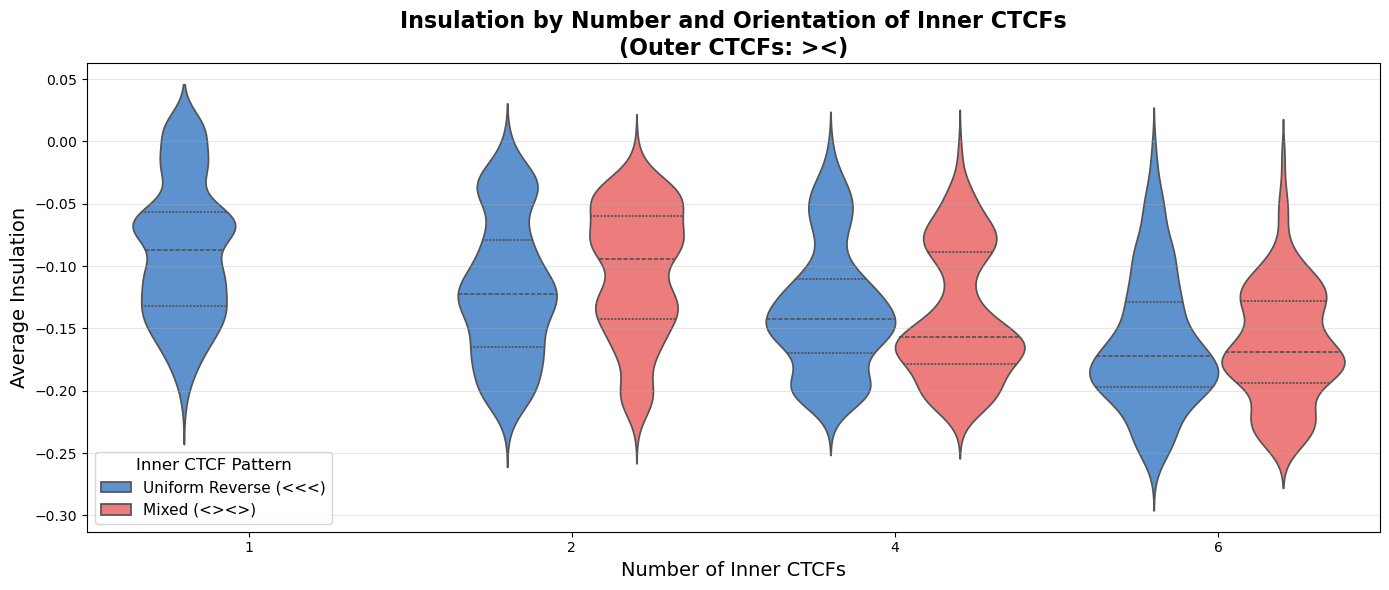

In [14]:
fig, ax = create_violin_plot(df, save_path='insulation_violin.png')
plt.show()

In [15]:
df.columns


Index(['experiment_id', 'ctcf_id', 'ctcf_index', 'background_idx',
       'background_length', 'ctcf_seq', 'configuration', 'outer_config',
       'num_ctcfs', 'num_middle_ctcfs', 'middle_config', 'ctcf_positions',
       'ctcf_orientations', 'outer_span_kb', 'middle_separation_bp',
       'num_ctcfs.1', 'num_middle_ctcfs.1', 'middle_config.1',
       'avg_insulation', 'std_insulation', 'avg_outer_dot_score'],
      dtype='object')

In [20]:
def classify_inner_orientation(ctcf_orientations_str):
    """
    Classify inner CTCF orientations as 'uniform' or 'mixed'
    """
    if ctcf_orientations_str == '[]':
        return 'control'
    
    try:
        orientations = literal_eval(ctcf_orientations_str)
    except:
        return 'unknown'
    
    if len(orientations) <= 2:
        return 'control'
    
    # Get inner CTCFs (exclude first and last which are outer CTCFs)
    inner_ctcfs = orientations[1:-1]
    
    # Check if all inner CTCFs have the same orientation
    if len(set(inner_ctcfs)) == 1:
        if inner_ctcfs[0] == 'reverse':
            return 'uniform'  # Simplified to just 'uniform'
        else:
            return 'uniform'
    else:
        return 'mixed'

In [21]:
def prepare_dumbbell_data(df, n_inner_ctcfs=2):
    """
    Prepare data for dumbbell plot
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze (default: 2)
    
    Returns:
    --------
    pd.DataFrame : Data for plotting with columns:
                   ctcf_id, uniform_avg, mixed_avg, change
    """
    # Filter for specific number of inner CTCFs
    df_subset = df[df['num_middle_ctcfs'] == n_inner_ctcfs].copy()
    
    # Classify orientations
    df_subset['orientation_type'] = df_subset['ctcf_orientations'].apply(
        classify_inner_orientation
    )
    
    # Keep only uniform and mixed
    df_subset = df_subset[df_subset['orientation_type'].isin(['uniform', 'mixed'])].copy()
    
    # Calculate average insulation for each CTCF × orientation type
    # (averaged over all 10 backgrounds)
    summary = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_insulation'].mean().reset_index()
    
    # Pivot to get uniform and mixed as columns
    pivot = summary.pivot(index='ctcf_id', columns='orientation_type', values='avg_insulation')
    
    # Calculate change
    pivot['change'] = pivot['mixed'] - pivot['uniform']
    pivot['abs_change'] = np.abs(pivot['change'])
    
    # Reset index
    pivot = pivot.reset_index()
    
    # Rename columns for clarity
    pivot = pivot.rename(columns={
        'uniform': 'uniform_avg',
        'mixed': 'mixed_avg'
    })
    
    # Sort by change (most negative to most positive)
    pivot = pivot.sort_values('change')
    
    return pivot

In [22]:
def create_dumbbell_plot(df, n_inner_ctcfs=2, save_path='dumbbell_plot.png', 
                         top_n=None, show_all=True):
    """
    Create dumbbell plot showing change from uniform to mixed for each CTCF
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    save_path : str
        Path to save the figure
    top_n : int or None
        If specified, only show top N CTCFs by absolute change
    show_all : bool
        If False and many CTCFs, show only top_n
    
    Returns:
    --------
    fig, ax : matplotlib figure and axis
    pd.DataFrame : Summary data used for plotting
    """
    # Prepare data
    data = prepare_dumbbell_data(df, n_inner_ctcfs)
    
    # Filter to top N if requested
    if top_n is not None:
        data = data.nlargest(top_n, 'abs_change')
        data = data.sort_values('change')
    elif not show_all and len(data) > 30:
        # If too many CTCFs, show top 30 by default
        print(f"Found {len(data)} CTCFs. Showing top 30 by absolute change.")
        data = data.nlargest(30, 'abs_change')
        data = data.sort_values('change')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, max(8, len(data) * 0.3)))
    
    # Create y-positions
    y_positions = np.arange(len(data))
    
    # Plot dumbbells
    for idx, (y_pos, row) in enumerate(zip(y_positions, data.itertuples())):
        # Determine color based on direction of change
        if row.change < 0:
            color = '#E74C3C'  # Red (decrease)
            marker_uniform = 'o'
            marker_mixed = 's'
        else:
            color = '#3498DB'  # Blue (increase)
            marker_uniform = 's'
            marker_mixed = 'o'
        
        # Draw line
        ax.plot([row.uniform_avg, row.mixed_avg], [y_pos, y_pos], 
                color=color, linewidth=2, alpha=0.6, zorder=1)
        
        # Draw points
        ax.scatter(row.uniform_avg, y_pos, s=100, color=color, 
                  marker=marker_uniform, zorder=2, alpha=0.8, 
                  edgecolors='black', linewidths=1)
        ax.scatter(row.mixed_avg, y_pos, s=100, color=color, 
                  marker=marker_mixed, zorder=2, alpha=0.8,
                  edgecolors='black', linewidths=1)
    
    # Set y-axis labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(data['ctcf_id'].values, fontsize=9)
    
    # Labels and title
    ax.set_xlabel('Average Insulation (averaged over 10 backgrounds)', fontsize=12)
    ax.set_ylabel('CTCF ID', fontsize=12)
    ax.set_title(f'Change in Insulation: Uniform → Mixed Inner CTCFs\n'
                 f'(n_inner = {n_inner_ctcfs}, Outer CTCFs: ><)', 
                 fontsize=14, fontweight='bold')
    
    # Add vertical line at x=0 if it's in range
    xlim = ax.get_xlim()
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
               markersize=10, label='Uniform (<<<)', markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
               markersize=10, label='Mixed (<><>)', markeredgecolor='black'),
        Line2D([0], [0], color='#E74C3C', linewidth=2, 
               label='Decrease (Mixed < Uniform)'),
        Line2D([0], [0], color='#3498DB', linewidth=2, 
               label='Increase (Mixed > Uniform)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    # Grid
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=data['uniform_avg'].mean(), color='purple', 
               linestyle='--', alpha=0.5, linewidth=1, label='Mean Uniform')
    ax.axvline(x=data['mixed_avg'].mean(), color='orange', 
               linestyle='--', alpha=0.5, linewidth=1, label='Mean Mixed')
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, ax, data

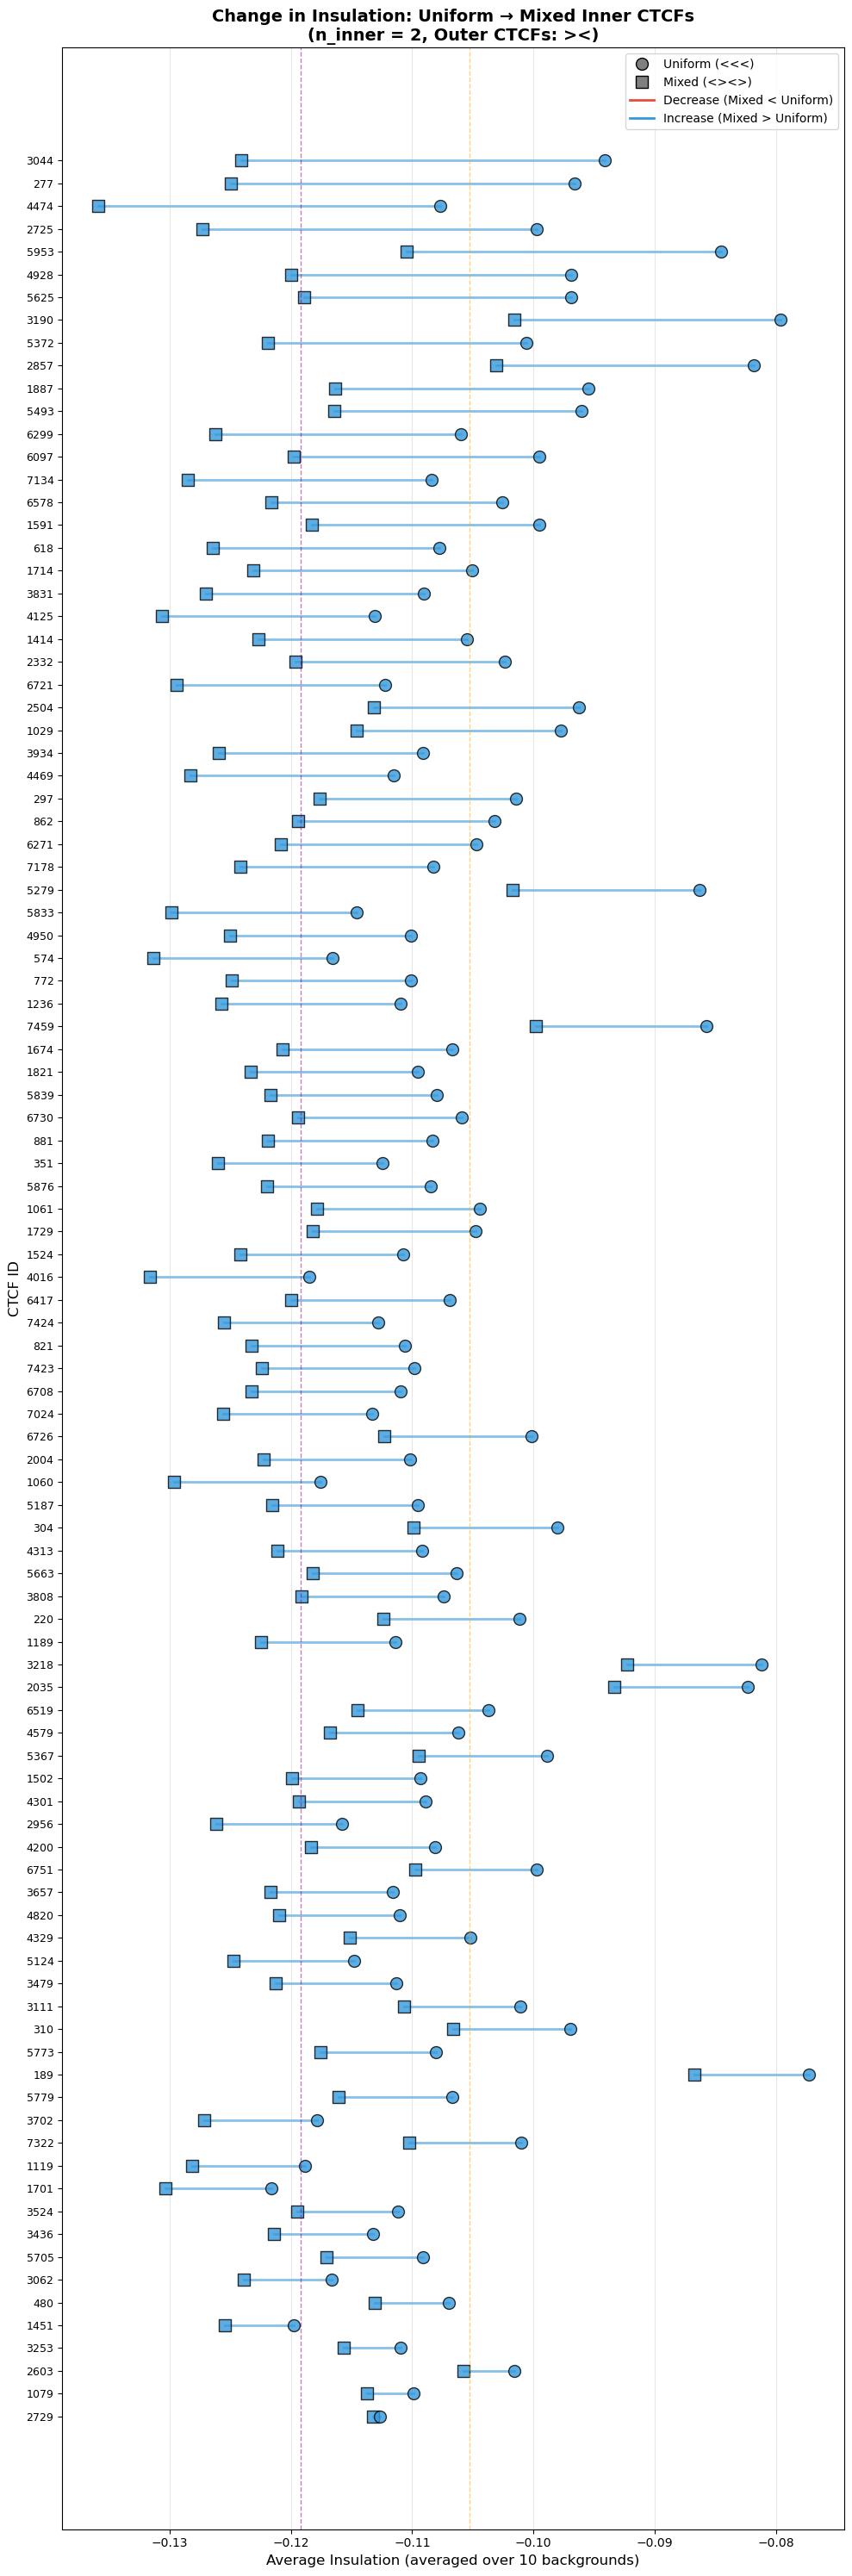

In [23]:
# Create dumbbell plot for 2 inner CTCFs
fig, ax, data = create_dumbbell_plot(df, n_inner_ctcfs=2, 
                                     save_path='dumbbell_2inner.png')

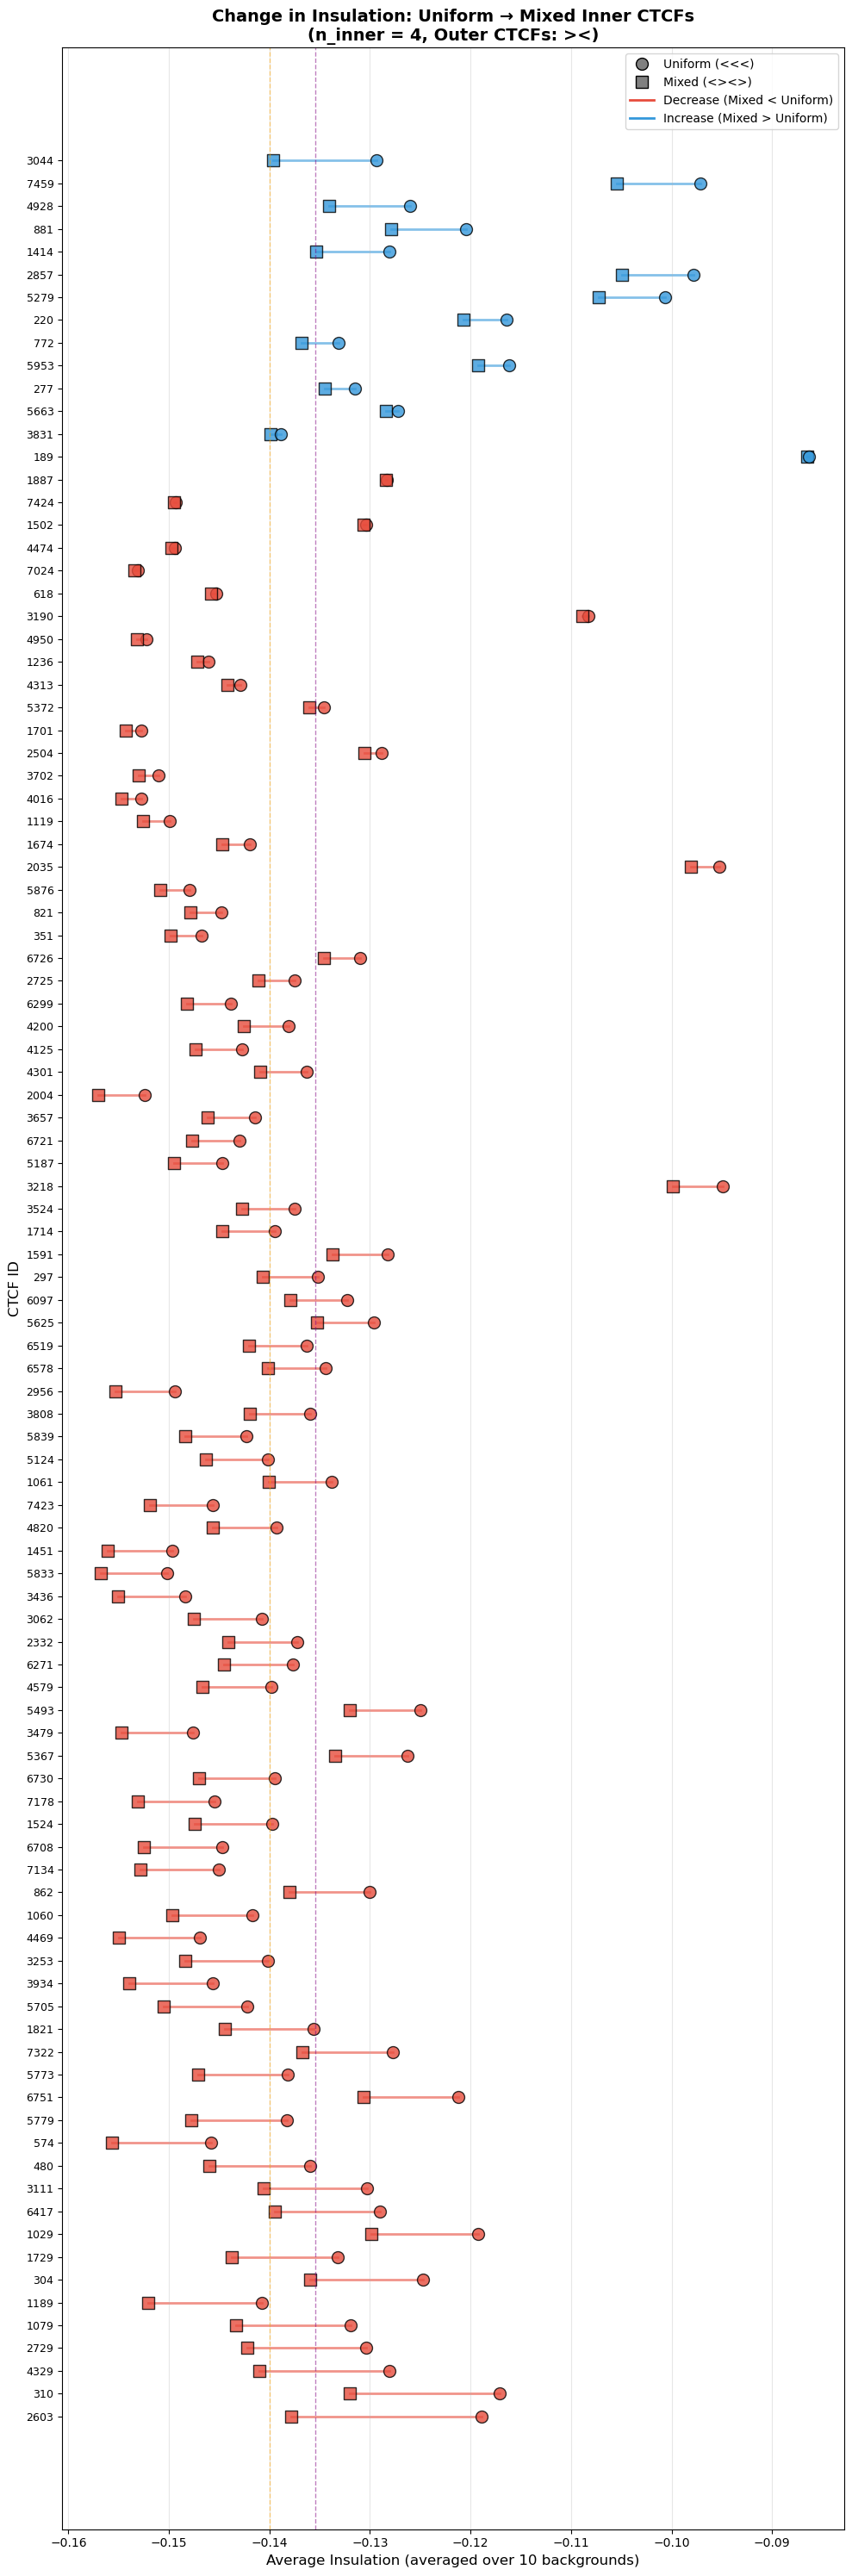

In [24]:
# Create dumbbell plot for 2 inner CTCFs
fig, ax, data = create_dumbbell_plot(df, n_inner_ctcfs=4, 
                                     save_path='dumbbell_2inner.png')

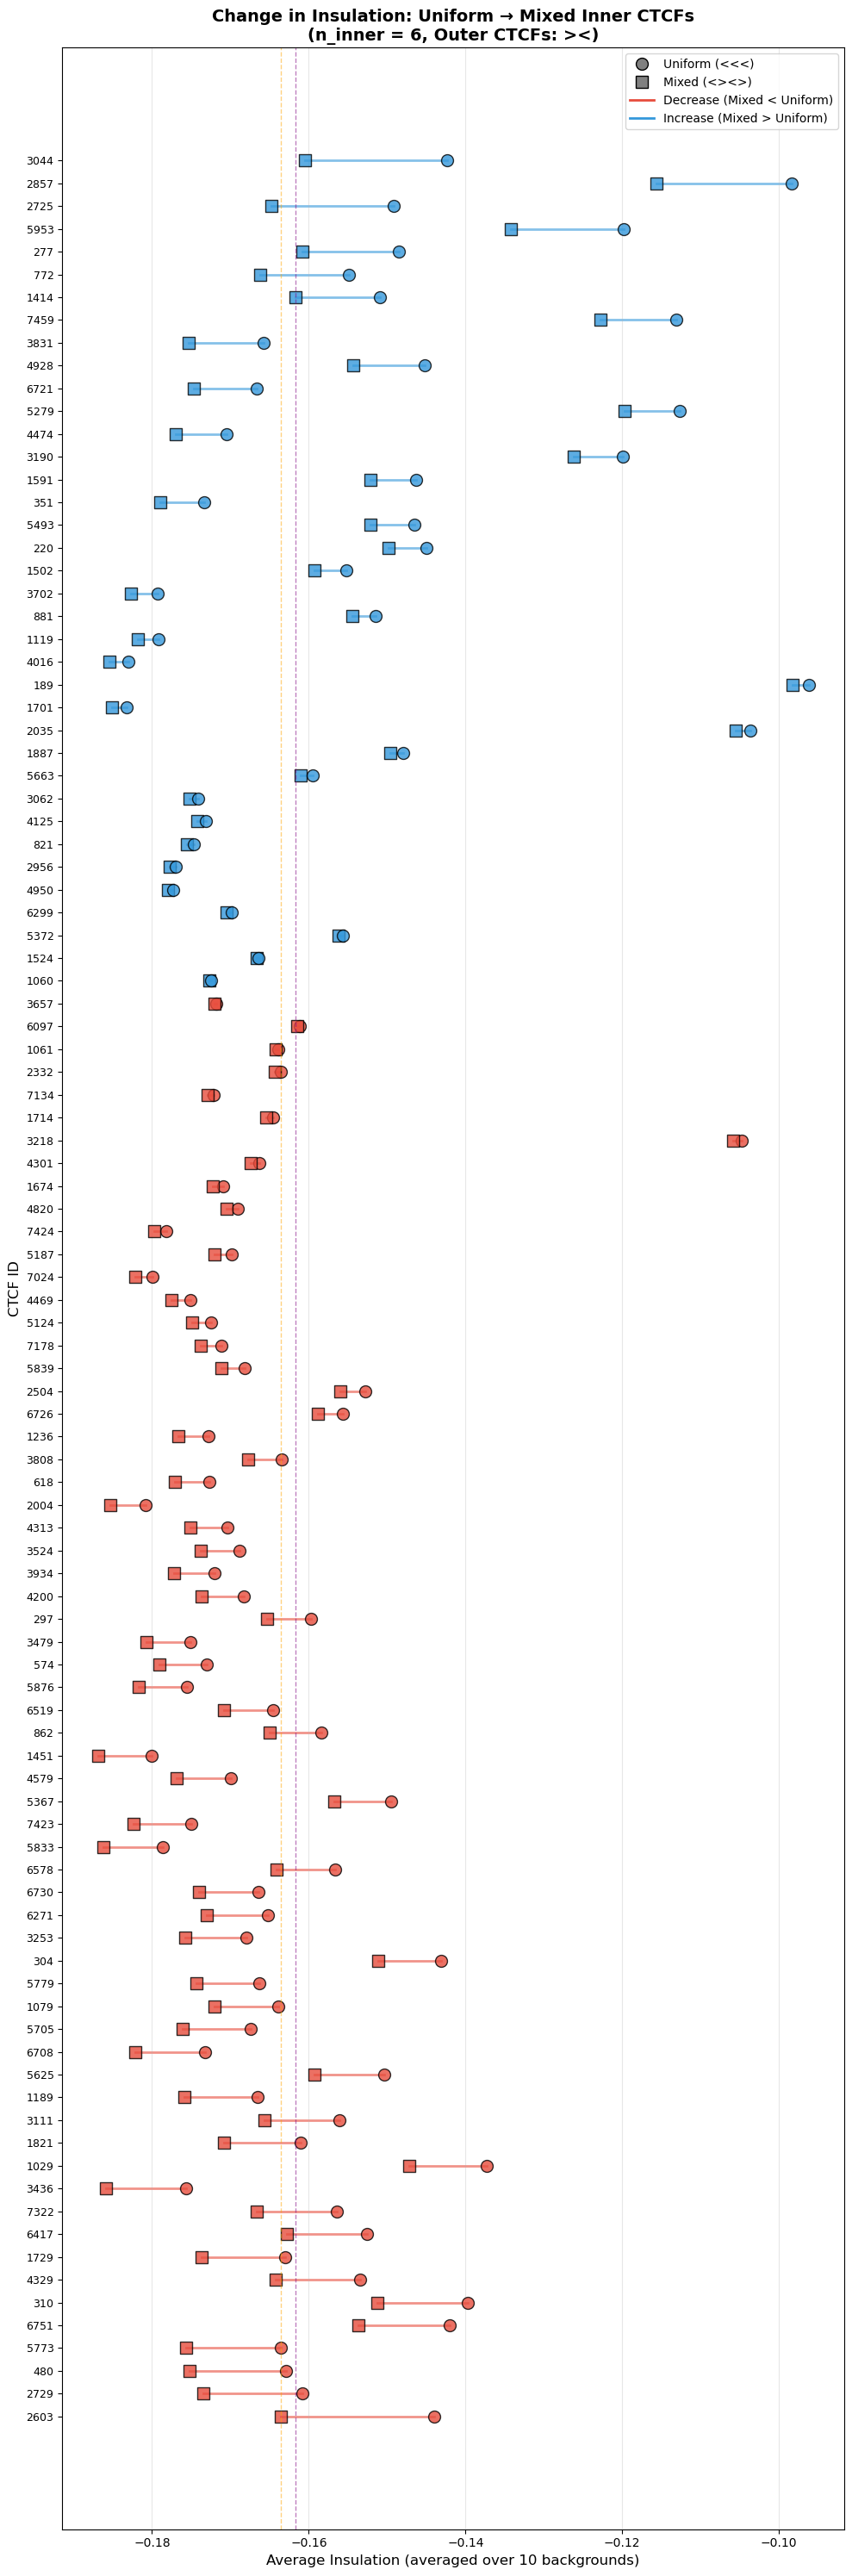

In [25]:
# Create dumbbell plot for 2 inner CTCFs
fig, ax, data = create_dumbbell_plot(df, n_inner_ctcfs=6, 
                                     save_path='dumbbell_2inner.png')

In [26]:
def get_change_by_ctcf_and_n_inner(df, n_inner_list=[2, 4, 6]):
    """
    Calculate change (mixed - uniform) for each CTCF across different numbers of inner CTCFs
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_list : list
        List of numbers of inner CTCFs to analyze
    
    Returns:
    --------
    pd.DataFrame : Wide format with ctcf_id as rows, n_inner as columns
    """
    all_changes = []
    
    for n_inner in n_inner_list:
        # Filter for specific number of inner CTCFs
        df_subset = df[df['num_middle_ctcfs'] == n_inner].copy()
        
        # Classify orientations
        df_subset['orientation_type'] = df_subset['ctcf_orientations'].apply(
            classify_inner_orientation
        )
        
        # Keep only uniform and mixed
        df_subset = df_subset[df_subset['orientation_type'].isin(['uniform', 'mixed'])].copy()
        
        # Calculate average for each CTCF × orientation (averaged over backgrounds)
        summary = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_insulation'].mean().reset_index()
        
        # Pivot to get uniform and mixed as columns
        pivot = summary.pivot(index='ctcf_id', columns='orientation_type', values='avg_insulation')
        
        # Calculate change
        pivot[f'change_{n_inner}'] = pivot['mixed'] - pivot['uniform']
        pivot[f'uniform_{n_inner}'] = pivot['uniform']
        pivot[f'mixed_{n_inner}'] = pivot['mixed']
        
        # Keep only change column
        change_col = pivot[[f'change_{n_inner}']].copy()
        all_changes.append(change_col)
    
    # Merge all changes
    result = pd.concat(all_changes, axis=1)
    result = result.reset_index()
    
    return result

In [27]:
def find_consistent_ctcfs(df, n_inner_list=[2, 4, 6], direction='increase'):
    """
    Find CTCFs that consistently increase or decrease
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_list : list
        List of numbers of inner CTCFs to analyze
    direction : str
        'increase' (mixed > uniform) or 'decrease' (mixed < uniform)
    
    Returns:
    --------
    pd.DataFrame : CTCFs meeting the criteria
    """
    # Get change data
    change_data = get_change_by_ctcf_and_n_inner(df, n_inner_list)
    
    # Get change columns
    change_cols = [f'change_{n}' for n in n_inner_list]
    
    if direction == 'increase':
        # All changes must be positive (mixed > uniform)
        mask = (change_data[change_cols] > 0).all(axis=1)
    elif direction == 'decrease':
        # All changes must be negative (mixed < uniform)
        mask = (change_data[change_cols] < 0).all(axis=1)
    else:
        raise ValueError("direction must be 'increase' or 'decrease'")
    
    consistent_ctcfs = change_data[mask].copy()
    
    # Add summary statistics
    consistent_ctcfs['mean_change'] = change_data[change_cols].mean(axis=1)[mask]
    consistent_ctcfs['std_change'] = change_data[change_cols].std(axis=1)[mask]
    consistent_ctcfs['min_change'] = change_data[change_cols].min(axis=1)[mask]
    consistent_ctcfs['max_change'] = change_data[change_cols].max(axis=1)[mask]
    
    # Sort by mean change
    if direction == 'increase':
        consistent_ctcfs = consistent_ctcfs.sort_values('mean_change', ascending=False)
    else:
        consistent_ctcfs = consistent_ctcfs.sort_values('mean_change', ascending=True)
    
    return consistent_ctcfs

In [28]:
def print_consistent_ctcfs_summary(df, n_inner_list=[2, 4, 6]):
    """
    Print summary of CTCFs with consistent behavior
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_list : list
        List of numbers of inner CTCFs to analyze
    """
    print("="*80)
    print("CONSISTENT CTCF BEHAVIOR ANALYSIS")
    print("="*80)
    print(f"\nAnalyzing {n_inner_list} inner CTCFs")
    
    # Get all CTCFs
    all_changes = get_change_by_ctcf_and_n_inner(df, n_inner_list)
    total_ctcfs = len(all_changes)
    
    print(f"Total CTCFs analyzed: {total_ctcfs}")
    
    # Find consistent increasers
    increasers = find_consistent_ctcfs(df, n_inner_list, direction='increase')
    n_increase = len(increasers)
    
    print(f"\n{'='*80}")
    print(f"CTCFs with CONSISTENT INCREASE (Mixed > Uniform for ALL n_inner)")
    print(f"{'='*80}")
    print(f"Count: {n_increase} ({n_increase/total_ctcfs*100:.1f}% of all CTCFs)")
    
    if n_increase > 0:
        print("\nTop CTCFs by average change:")
        display_cols = ['ctcf_id'] + [f'change_{n}' for n in n_inner_list] + ['mean_change']
        print(increasers[display_cols].head(10).to_string(index=False))
    else:
        print("No CTCFs consistently increase across all conditions.")
    
    # Find consistent decreasers
    decreasers = find_consistent_ctcfs(df, n_inner_list, direction='decrease')
    n_decrease = len(decreasers)
    
    print(f"\n{'='*80}")
    print(f"CTCFs with CONSISTENT DECREASE (Mixed < Uniform for ALL n_inner)")
    print(f"{'='*80}")
    print(f"Count: {n_decrease} ({n_decrease/total_ctcfs*100:.1f}% of all CTCFs)")
    
    if n_decrease > 0:
        print("\nTop CTCFs by average change (most negative):")
        display_cols = ['ctcf_id'] + [f'change_{n}' for n in n_inner_list] + ['mean_change']
        print(decreasers[display_cols].head(10).to_string(index=False))
    else:
        print("No CTCFs consistently decrease across all conditions.")
    
    # Find inconsistent (mixed behavior)
    n_inconsistent = total_ctcfs - n_increase - n_decrease
    print(f"\n{'='*80}")
    print(f"CTCFs with INCONSISTENT behavior")
    print(f"{'='*80}")
    print(f"Count: {n_inconsistent} ({n_inconsistent/total_ctcfs*100:.1f}% of all CTCFs)")
    print("(These CTCFs increase for some n_inner and decrease for others)")
    
    return {
        'all_changes': all_changes,
        'consistent_increase': increasers,
        'consistent_decrease': decreasers
    }


In [29]:
def create_consistency_heatmap(df, n_inner_list=[2, 4, 6], 
                               save_path='ctcf_consistency_heatmap.png'):
    """
    Create heatmap showing change for each CTCF across different n_inner
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_list : list
        List of numbers of inner CTCFs to analyze
    save_path : str
        Path to save figure
    """
    # Get change data
    change_data = get_change_by_ctcf_and_n_inner(df, n_inner_list)
    
    # Get change columns and reorder
    change_cols = [f'change_{n}' for n in n_inner_list]
    heatmap_data = change_data.set_index('ctcf_id')[change_cols]
    
    # Rename columns for display
    heatmap_data.columns = [f'{n} inner' for n in n_inner_list]
    
    # Sort by mean change
    heatmap_data['mean'] = heatmap_data.mean(axis=1)
    heatmap_data = heatmap_data.sort_values('mean', ascending=False)
    heatmap_data = heatmap_data.drop('mean', axis=1)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, max(10, len(heatmap_data) * 0.3)))
    
    # Create heatmap
    sns.heatmap(
        heatmap_data,
        cmap='RdBu_r',
        center=0,
        cbar_kws={'label': 'Change in Insulation\n(Mixed - Uniform)'},
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        ax=ax
    )
    
    ax.set_xlabel('Number of Inner CTCFs', fontsize=12)
    ax.set_ylabel('CTCF ID', fontsize=12)
    ax.set_title('Consistency of CTCF Response to Mixed Orientations\n(Outer CTCFs: ><)', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, ax

In [30]:
def create_consistency_plot(df, n_inner_list=[2, 4, 6],
                            save_path='ctcf_consistency_plot.png'):
    """
    Create line plot showing how each CTCF changes across n_inner values
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_list : list
        List of numbers of inner CTCFs to analyze
    save_path : str
        Path to save figure
    """
    # Get change data
    change_data = get_change_by_ctcf_and_n_inner(df, n_inner_list)
    
    # Identify consistent CTCFs
    increasers = find_consistent_ctcfs(df, n_inner_list, direction='increase')
    decreasers = find_consistent_ctcfs(df, n_inner_list, direction='decrease')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each CTCF
    for idx, row in change_data.iterrows():
        ctcf_id = row['ctcf_id']
        changes = [row[f'change_{n}'] for n in n_inner_list]
        
        # Determine color and style
        if ctcf_id in increasers['ctcf_id'].values:
            color = '#2E86AB'  # Blue
            alpha = 0.8
            linewidth = 2
            label = 'Consistent Increase' if idx == 0 else None
        elif ctcf_id in decreasers['ctcf_id'].values:
            color = '#A23B72'  # Purple
            alpha = 0.8
            linewidth = 2
            label = 'Consistent Decrease' if idx == 0 else None
        else:
            color = 'gray'
            alpha = 0.3
            linewidth = 1
            label = 'Inconsistent' if idx == 0 else None
        
        ax.plot(n_inner_list, changes, 'o-', color=color, alpha=alpha, 
               linewidth=linewidth, markersize=6, label=label)
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # Labels and formatting
    ax.set_xlabel('Number of Inner CTCFs', fontsize=12)
    ax.set_ylabel('Change in Insulation (Mixed - Uniform)', fontsize=12)
    ax.set_title('CTCF Response Consistency Across Different Numbers of Inner CTCFs\n(Outer CTCFs: ><)', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(n_inner_list)
    ax.grid(True, alpha=0.3)
    
    # Legend (remove duplicates)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=10, loc='best')
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, ax



In [31]:
results = print_consistent_ctcfs_summary(df, n_inner_list=[2, 4, 6])

CONSISTENT CTCF BEHAVIOR ANALYSIS

Analyzing [2, 4, 6] inner CTCFs
Total CTCFs analyzed: 100

CTCFs with CONSISTENT INCREASE (Mixed > Uniform for ALL n_inner)
Count: 14 (14.0% of all CTCFs)

Top CTCFs by average change:
 ctcf_id  change_2  change_4  change_6  mean_change
    3044  0.029946  0.010242  0.018136     0.019441
    2857  0.021247  0.007130  0.017312     0.015230
     277  0.028310  0.003078  0.012224     0.014537
    5953  0.025914  0.003150  0.014352     0.014472
    4928  0.023059  0.008122  0.009088     0.013423
    1414  0.017235  0.007261  0.010803     0.011766
    7459  0.014080  0.008367  0.009643     0.010697
     772  0.014790  0.003662  0.011254     0.009902
    5279  0.015410  0.006564  0.006995     0.009656
    3831  0.017913  0.001024  0.009514     0.009484

CTCFs with CONSISTENT DECREASE (Mixed < Uniform for ALL n_inner)
Count: 0 (0.0% of all CTCFs)
No CTCFs consistently decrease across all conditions.

CTCFs with INCONSISTENT behavior
Count: 86 (86.0% of all C

In [32]:
# Access specific groups
consistent_increase = results['consistent_increase']
consistent_decrease = results['consistent_decrease']

print(f"\\nCTCFs that ALWAYS increase (mixed > uniform):")
print(consistent_increase['ctcf_id'].tolist())

print(f"\\nCTCFs that ALWAYS decrease (mixed < uniform):")
print(consistent_decrease['ctcf_id'].tolist())

\nCTCFs that ALWAYS increase (mixed > uniform):
[3044, 2857, 277, 5953, 4928, 1414, 7459, 772, 5279, 3831, 881, 220, 5663, 189]
\nCTCFs that ALWAYS decrease (mixed < uniform):
[]


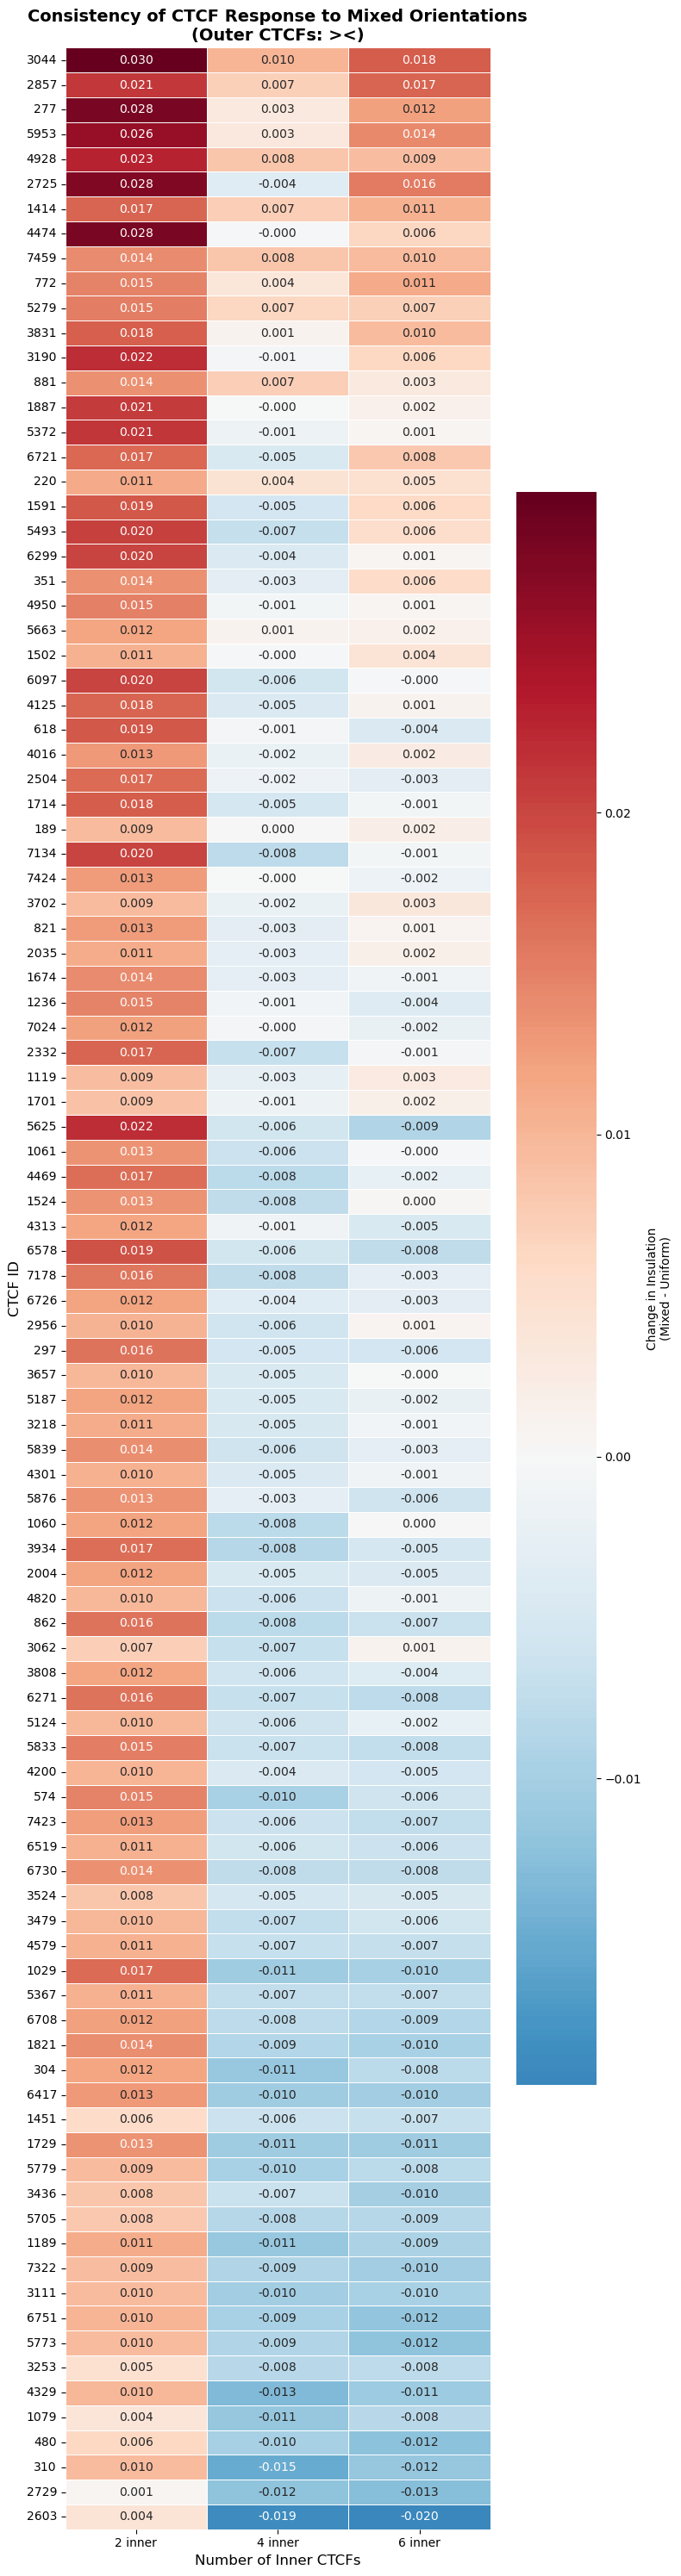

(<Figure size 800x3000 with 2 Axes>,
 <Axes: title={'center': 'Consistency of CTCF Response to Mixed Orientations\n(Outer CTCFs: ><)'}, xlabel='Number of Inner CTCFs', ylabel='CTCF ID'>)

In [33]:
# Create visualizations
create_consistency_heatmap(df, n_inner_list=[2, 4, 6], 
                          save_path='consistency_heatmap.png')

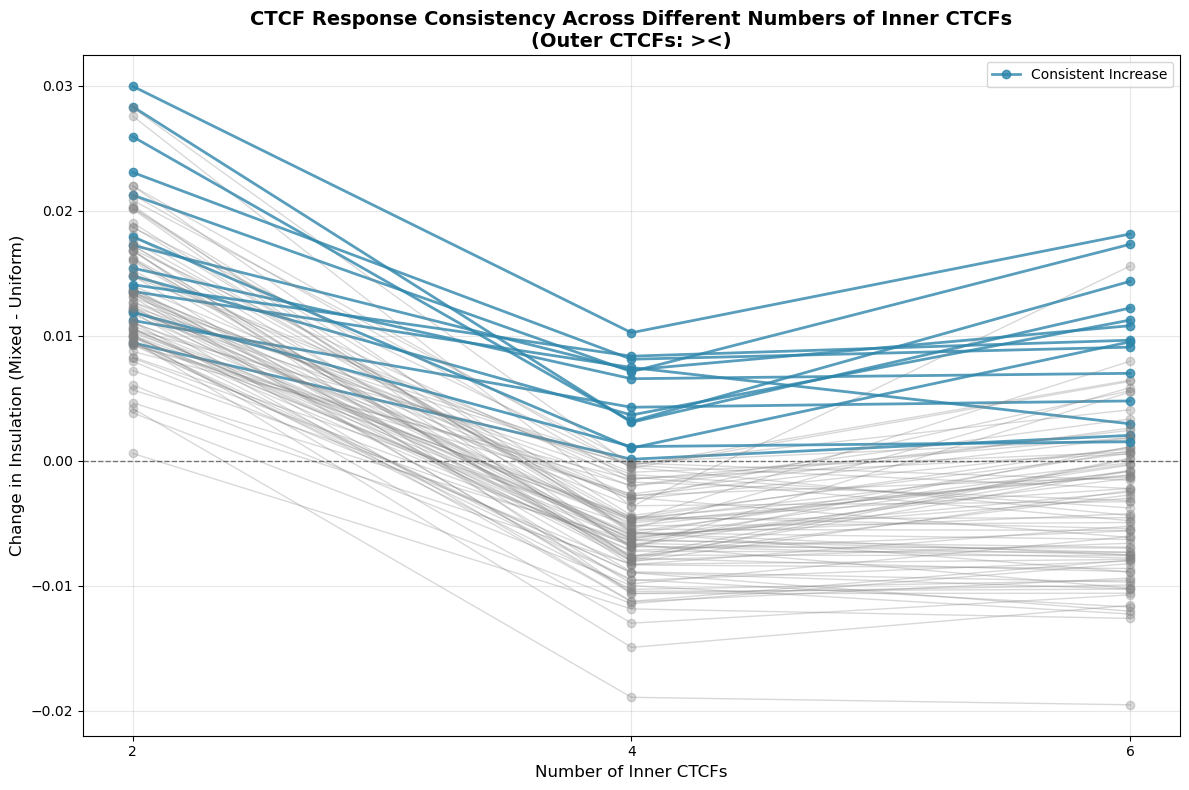

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'CTCF Response Consistency Across Different Numbers of Inner CTCFs\n(Outer CTCFs: ><)'}, xlabel='Number of Inner CTCFs', ylabel='Change in Insulation (Mixed - Uniform)'>)

In [34]:
create_consistency_plot(df, n_inner_list=[2, 4, 6],
                       save_path='consistency_plot.png')

In [35]:
always_increase = find_consistent_ctcfs(df, n_inner_list=[2, 4, 6], 
                                       direction='increase')

In [36]:
always_increase

orientation_type,ctcf_id,change_2,change_4,change_6,mean_change,std_change,min_change,max_change
41,3044,0.029946,0.010242,0.018136,0.019441,0.009917,0.010242,0.029946
39,2857,0.021247,0.007130,0.017312,0.015230,0.007286,0.007130,0.021247
2,277,0.028310,0.003078,0.012224,0.014537,0.012774,0.003078,0.028310
81,5953,0.025914,0.003150,0.014352,0.014472,0.011383,0.003150,0.025914
65,4928,0.023059,0.008122,0.009088,0.013423,0.008359,0.008122,0.023059
21,1414,0.017235,0.007261,0.010803,0.011766,0.005056,0.007261,0.017235
99,7459,0.014080,0.008367,0.009643,0.010697,0.002998,0.008367,0.014080
10,772,0.014790,0.003662,0.011254,0.009902,0.005686,0.003662,0.014790
69,5279,0.015410,0.006564,0.006995,0.009656,0.004987,0.006564,0.015410
53,3831,0.017913,0.001024,0.009514,0.009484,0.008444,0.001024,0.017913


In [37]:
def prepare_dual_metric_data(df, n_inner_ctcfs=2):
    """
    Prepare data for both insulation and dot score
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    
    Returns:
    --------
    pd.DataFrame : Data with both metrics
    """
    # Filter for specific number of inner CTCFs
    df_subset = df[df['num_middle_ctcfs'] == n_inner_ctcfs].copy()
    
    # Classify orientations
    df_subset['orientation_type'] = df_subset['ctcf_orientations'].apply(
        classify_inner_orientation
    )
    
    # Keep only uniform and mixed
    df_subset = df_subset[df_subset['orientation_type'].isin(['uniform', 'mixed'])].copy()
    
    # Calculate averages for each CTCF × orientation (averaged over backgrounds)
    summary_insulation = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_insulation'].mean().reset_index()
    summary_dot = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_outer_dot_score'].mean().reset_index()
    
    # Pivot for insulation
    pivot_insulation = summary_insulation.pivot(index='ctcf_id', columns='orientation_type', values='avg_insulation')
    pivot_insulation['insulation_change'] = pivot_insulation['mixed'] - pivot_insulation['uniform']
    pivot_insulation['insulation_uniform'] = pivot_insulation['uniform']
    pivot_insulation['insulation_mixed'] = pivot_insulation['mixed']
    
    # Pivot for dot score
    pivot_dot = summary_dot.pivot(index='ctcf_id', columns='orientation_type', values='avg_outer_dot_score')
    pivot_dot['dot_change'] = pivot_dot['mixed'] - pivot_dot['uniform']
    pivot_dot['dot_uniform'] = pivot_dot['uniform']
    pivot_dot['dot_mixed'] = pivot_dot['mixed']
    
    # Merge
    result = pd.merge(
        pivot_insulation[['insulation_uniform', 'insulation_mixed', 'insulation_change']],
        pivot_dot[['dot_uniform', 'dot_mixed', 'dot_change']],
        left_index=True,
        right_index=True
    )
    
    result = result.reset_index()
    
    return result


In [38]:
def create_dot_score_dumbbell(df, n_inner_ctcfs=2, save_path='dot_score_dumbbell.png', 
                               top_n=None):
    """
    Create dumbbell plot for dot score changes
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    save_path : str
        Path to save the figure
    top_n : int or None
        If specified, only show top N CTCFs by absolute change
    
    Returns:
    --------
    fig, ax, data
    """
    # Prepare data
    data = prepare_dual_metric_data(df, n_inner_ctcfs)
    
    # Sort by dot score change
    data = data.sort_values('dot_change')
    
    # Filter to top N if requested
    if top_n is not None:
        data['abs_dot_change'] = np.abs(data['dot_change'])
        data = data.nlargest(top_n, 'abs_dot_change')
        data = data.sort_values('dot_change')
    elif len(data) > 30:
        print(f"Found {len(data)} CTCFs. Showing top 30 by absolute change.")
        data['abs_dot_change'] = np.abs(data['dot_change'])
        data = data.nlargest(30, 'abs_dot_change')
        data = data.sort_values('dot_change')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, max(8, len(data) * 0.3)))
    
    # Create y-positions
    y_positions = np.arange(len(data))
    
    # Plot dumbbells
    for idx, (y_pos, row) in enumerate(zip(y_positions, data.itertuples())):
        # Determine color based on direction of change
        if row.dot_change < 0:
            color = '#E74C3C'  # Red (decrease)
        else:
            color = '#3498DB'  # Blue (increase)
        
        # Draw line
        ax.plot([row.dot_uniform, row.dot_mixed], [y_pos, y_pos], 
                color=color, linewidth=2, alpha=0.6, zorder=1)
        
        # Draw points
        ax.scatter(row.dot_uniform, y_pos, s=100, color=color, 
                  marker='o', zorder=2, alpha=0.8, 
                  edgecolors='black', linewidths=1)
        ax.scatter(row.dot_mixed, y_pos, s=100, color=color, 
                  marker='s', zorder=2, alpha=0.8,
                  edgecolors='black', linewidths=1)
    
    # Set y-axis labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(data['ctcf_id'].values, fontsize=9)
    
    # Labels and title
    ax.set_xlabel('Average Outer Dot Score (averaged over 10 backgrounds)', fontsize=12)
    ax.set_ylabel('CTCF ID', fontsize=12)
    ax.set_title(f'Change in Dot Score: Uniform → Mixed Inner CTCFs\n'
                 f'(n_inner = {n_inner_ctcfs}, Outer CTCFs: ><)', 
                 fontsize=14, fontweight='bold')
    
    # Add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
               markersize=10, label='Uniform (<<<)', markeredgecolor='black'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
               markersize=10, label='Mixed (<><>)', markeredgecolor='black'),
        Line2D([0], [0], color='#E74C3C', linewidth=2, 
               label='Decrease (Mixed < Uniform)'),
        Line2D([0], [0], color='#3498DB', linewidth=2, 
               label='Increase (Mixed > Uniform)')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    # Grid
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=data['dot_uniform'].mean(), color='purple', 
               linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=data['dot_mixed'].mean(), color='orange', 
               linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, ax, data


In [39]:
def create_dual_metric_comparison(df, n_inner_ctcfs=2, 
                                   save_path='insulation_vs_dot_comparison.png'):
    """
    Create side-by-side comparison of insulation and dot score changes
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    save_path : str
        Path to save figure
    """
    # Prepare data
    data = prepare_dual_metric_data(df, n_inner_ctcfs)
    
    # Sort by insulation change for consistency
    data = data.sort_values('insulation_change')
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(data) * 0.3)))
    
    # Create y-positions
    y_positions = np.arange(len(data))
    
    # PANEL 1: Insulation
    ax = axes[0]
    for idx, (y_pos, row) in enumerate(zip(y_positions, data.itertuples())):
        color = '#E74C3C' if row.insulation_change < 0 else '#3498DB'
        
        ax.plot([row.insulation_uniform, row.insulation_mixed], [y_pos, y_pos], 
                color=color, linewidth=2, alpha=0.6, zorder=1)
        ax.scatter(row.insulation_uniform, y_pos, s=80, color=color, 
                  marker='o', zorder=2, alpha=0.8, edgecolors='black', linewidths=1)
        ax.scatter(row.insulation_mixed, y_pos, s=80, color=color, 
                  marker='s', zorder=2, alpha=0.8, edgecolors='black', linewidths=1)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(data['ctcf_id'].values, fontsize=9)
    ax.set_xlabel('Average Insulation', fontsize=12)
    ax.set_ylabel('CTCF ID', fontsize=12)
    ax.set_title('Insulation Change', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=data['insulation_uniform'].mean(), color='purple', 
               linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=data['insulation_mixed'].mean(), color='orange', 
               linestyle='--', alpha=0.5, linewidth=1)
    
    # PANEL 2: Dot Score
    ax = axes[1]
    for idx, (y_pos, row) in enumerate(zip(y_positions, data.itertuples())):
        color = '#E74C3C' if row.dot_change < 0 else '#3498DB'
        
        ax.plot([row.dot_uniform, row.dot_mixed], [y_pos, y_pos], 
                color=color, linewidth=2, alpha=0.6, zorder=1)
        ax.scatter(row.dot_uniform, y_pos, s=80, color=color, 
                  marker='o', zorder=2, alpha=0.8, edgecolors='black', linewidths=1)
        ax.scatter(row.dot_mixed, y_pos, s=80, color=color, 
                  marker='s', zorder=2, alpha=0.8, edgecolors='black', linewidths=1)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels([])  # No labels on right plot
    ax.set_xlabel('Average Outer Dot Score', fontsize=12)
    ax.set_title('Dot Score Change', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=data['dot_uniform'].mean(), color='purple', 
               linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=data['dot_mixed'].mean(), color='orange', 
               linestyle='--', alpha=0.5, linewidth=1)
    
    # Overall title
    fig.suptitle(f'Insulation vs Dot Score Changes: Uniform → Mixed\n'
                 f'(n_inner = {n_inner_ctcfs}, Outer CTCFs: ><)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"✓ Saved: {save_path}")
    plt.show()
    
    return fig, axes, data


In [40]:
def create_correlation_plot(df, n_inner_ctcfs=2, 
                            save_path='insulation_dot_correlation.png'):
    """
    Create scatter plot showing correlation between insulation and dot score changes
    
    Tests hypothesis: increased insulation correlates with stronger dots
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    save_path : str
        Path to save figure
    """
    # Prepare data
    data = prepare_dual_metric_data(df, n_inner_ctcfs)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # PANEL 1: Change correlation
    ax = axes[0]
    
    # Calculate correlation
    corr, p_value = stats.pearsonr(data['insulation_change'], data['dot_change'])
    
    # Create scatter plot
    scatter = ax.scatter(
        data['insulation_change'],
        data['dot_change'],
        c=data['insulation_change'],
        cmap='RdBu_r',
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidths=1
    )
    
    # Add regression line
    z = np.polyfit(data['insulation_change'], data['dot_change'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(data['insulation_change'].min(), data['insulation_change'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Linear fit')
    
    # Add quadrant lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Labels
    ax.set_xlabel('Insulation Change (Mixed - Uniform)', fontsize=12)
    ax.set_ylabel('Dot Score Change (Mixed - Uniform)', fontsize=12)
    ax.set_title(f'Correlation: Insulation vs Dot Score Changes\n'
                 f'r = {corr:.3f}, p = {p_value:.2e}', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Insulation Change', fontsize=10)
    
    # PANEL 2: Quadrant analysis
    ax = axes[1]
    
    # Define quadrants
    quad1 = data[(data['insulation_change'] > 0) & (data['dot_change'] > 0)]  # Both increase
    quad2 = data[(data['insulation_change'] < 0) & (data['dot_change'] > 0)]  # Ins down, dot up
    quad3 = data[(data['insulation_change'] < 0) & (data['dot_change'] < 0)]  # Both decrease
    quad4 = data[(data['insulation_change'] > 0) & (data['dot_change'] < 0)]  # Ins up, dot down
    
    # Plot quadrants with different colors
    ax.scatter(quad1['insulation_change'], quad1['dot_change'], 
              s=100, alpha=0.6, label=f'Q1: Both ↑ (n={len(quad1)})', 
              color='#2E86AB', edgecolors='black', linewidths=1)
    ax.scatter(quad2['insulation_change'], quad2['dot_change'], 
              s=100, alpha=0.6, label=f'Q2: Ins↓ Dot↑ (n={len(quad2)})', 
              color='#A23B72', edgecolors='black', linewidths=1)
    ax.scatter(quad3['insulation_change'], quad3['dot_change'], 
              s=100, alpha=0.6, label=f'Q3: Both ↓ (n={len(quad3)})', 
              color='#F18F01', edgecolors='black', linewidths=1)
    ax.scatter(quad4['insulation_change'], quad4['dot_change'], 
              s=100, alpha=0.6, label=f'Q4: Ins↑ Dot↓ (n={len(quad4)})', 
              color='#C73E1D', edgecolors='black', linewidths=1)
    
    # Add quadrant lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Labels
    ax.set_xlabel('Insulation Change (Mixed - Uniform)', fontsize=12)
    ax.set_ylabel('Dot Score Change (Mixed - Uniform)', fontsize=12)
    ax.set_title('Quadrant Analysis', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {save_path}")
    
    # Print hypothesis test
    print("\n" + "="*80)
    print("HYPOTHESIS TEST: Increased Insulation → Stronger Dots")
    print("="*80)
    print(f"\nCorrelation coefficient: r = {corr:.3f}")
    print(f"P-value: {p_value:.2e}")
    
    if p_value < 0.05:
        if corr > 0:
            print("✓ HYPOTHESIS SUPPORTED: Significant positive correlation")
            print("  Sites with increased insulation tend to have stronger dots")
        else:
            print("✗ HYPOTHESIS NOT SUPPORTED: Significant negative correlation")
            print("  Sites with increased insulation tend to have weaker dots")
    else:
        print("? INCONCLUSIVE: No significant correlation")
    
    print(f"\nQuadrant distribution:")
    print(f"  Q1 (Both ↑):     {len(quad1):3d} ({len(quad1)/len(data)*100:.1f}%)")
    print(f"  Q2 (Ins↓ Dot↑):  {len(quad2):3d} ({len(quad2)/len(data)*100:.1f}%)")
    print(f"  Q3 (Both ↓):     {len(quad3):3d} ({len(quad3)/len(data)*100:.1f}%)")
    print(f"  Q4 (Ins↑ Dot↓):  {len(quad4):3d} ({len(quad4)/len(data)*100:.1f}%)")
    
    return fig, axes, data

Found 100 CTCFs. Showing top 30 by absolute change.


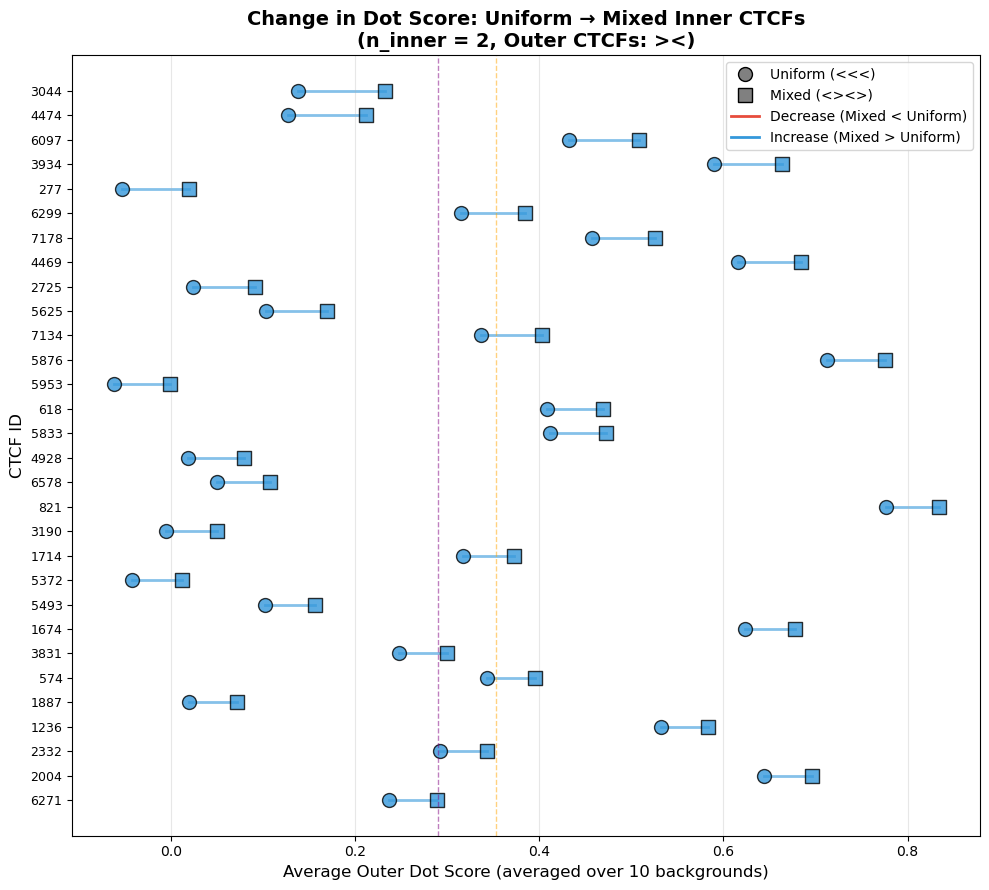

In [41]:
fig, ax, data = create_dot_score_dumbbell(df, n_inner_ctcfs=2,
                                          save_path='dot_score_dumbbell.png')
plt.show()

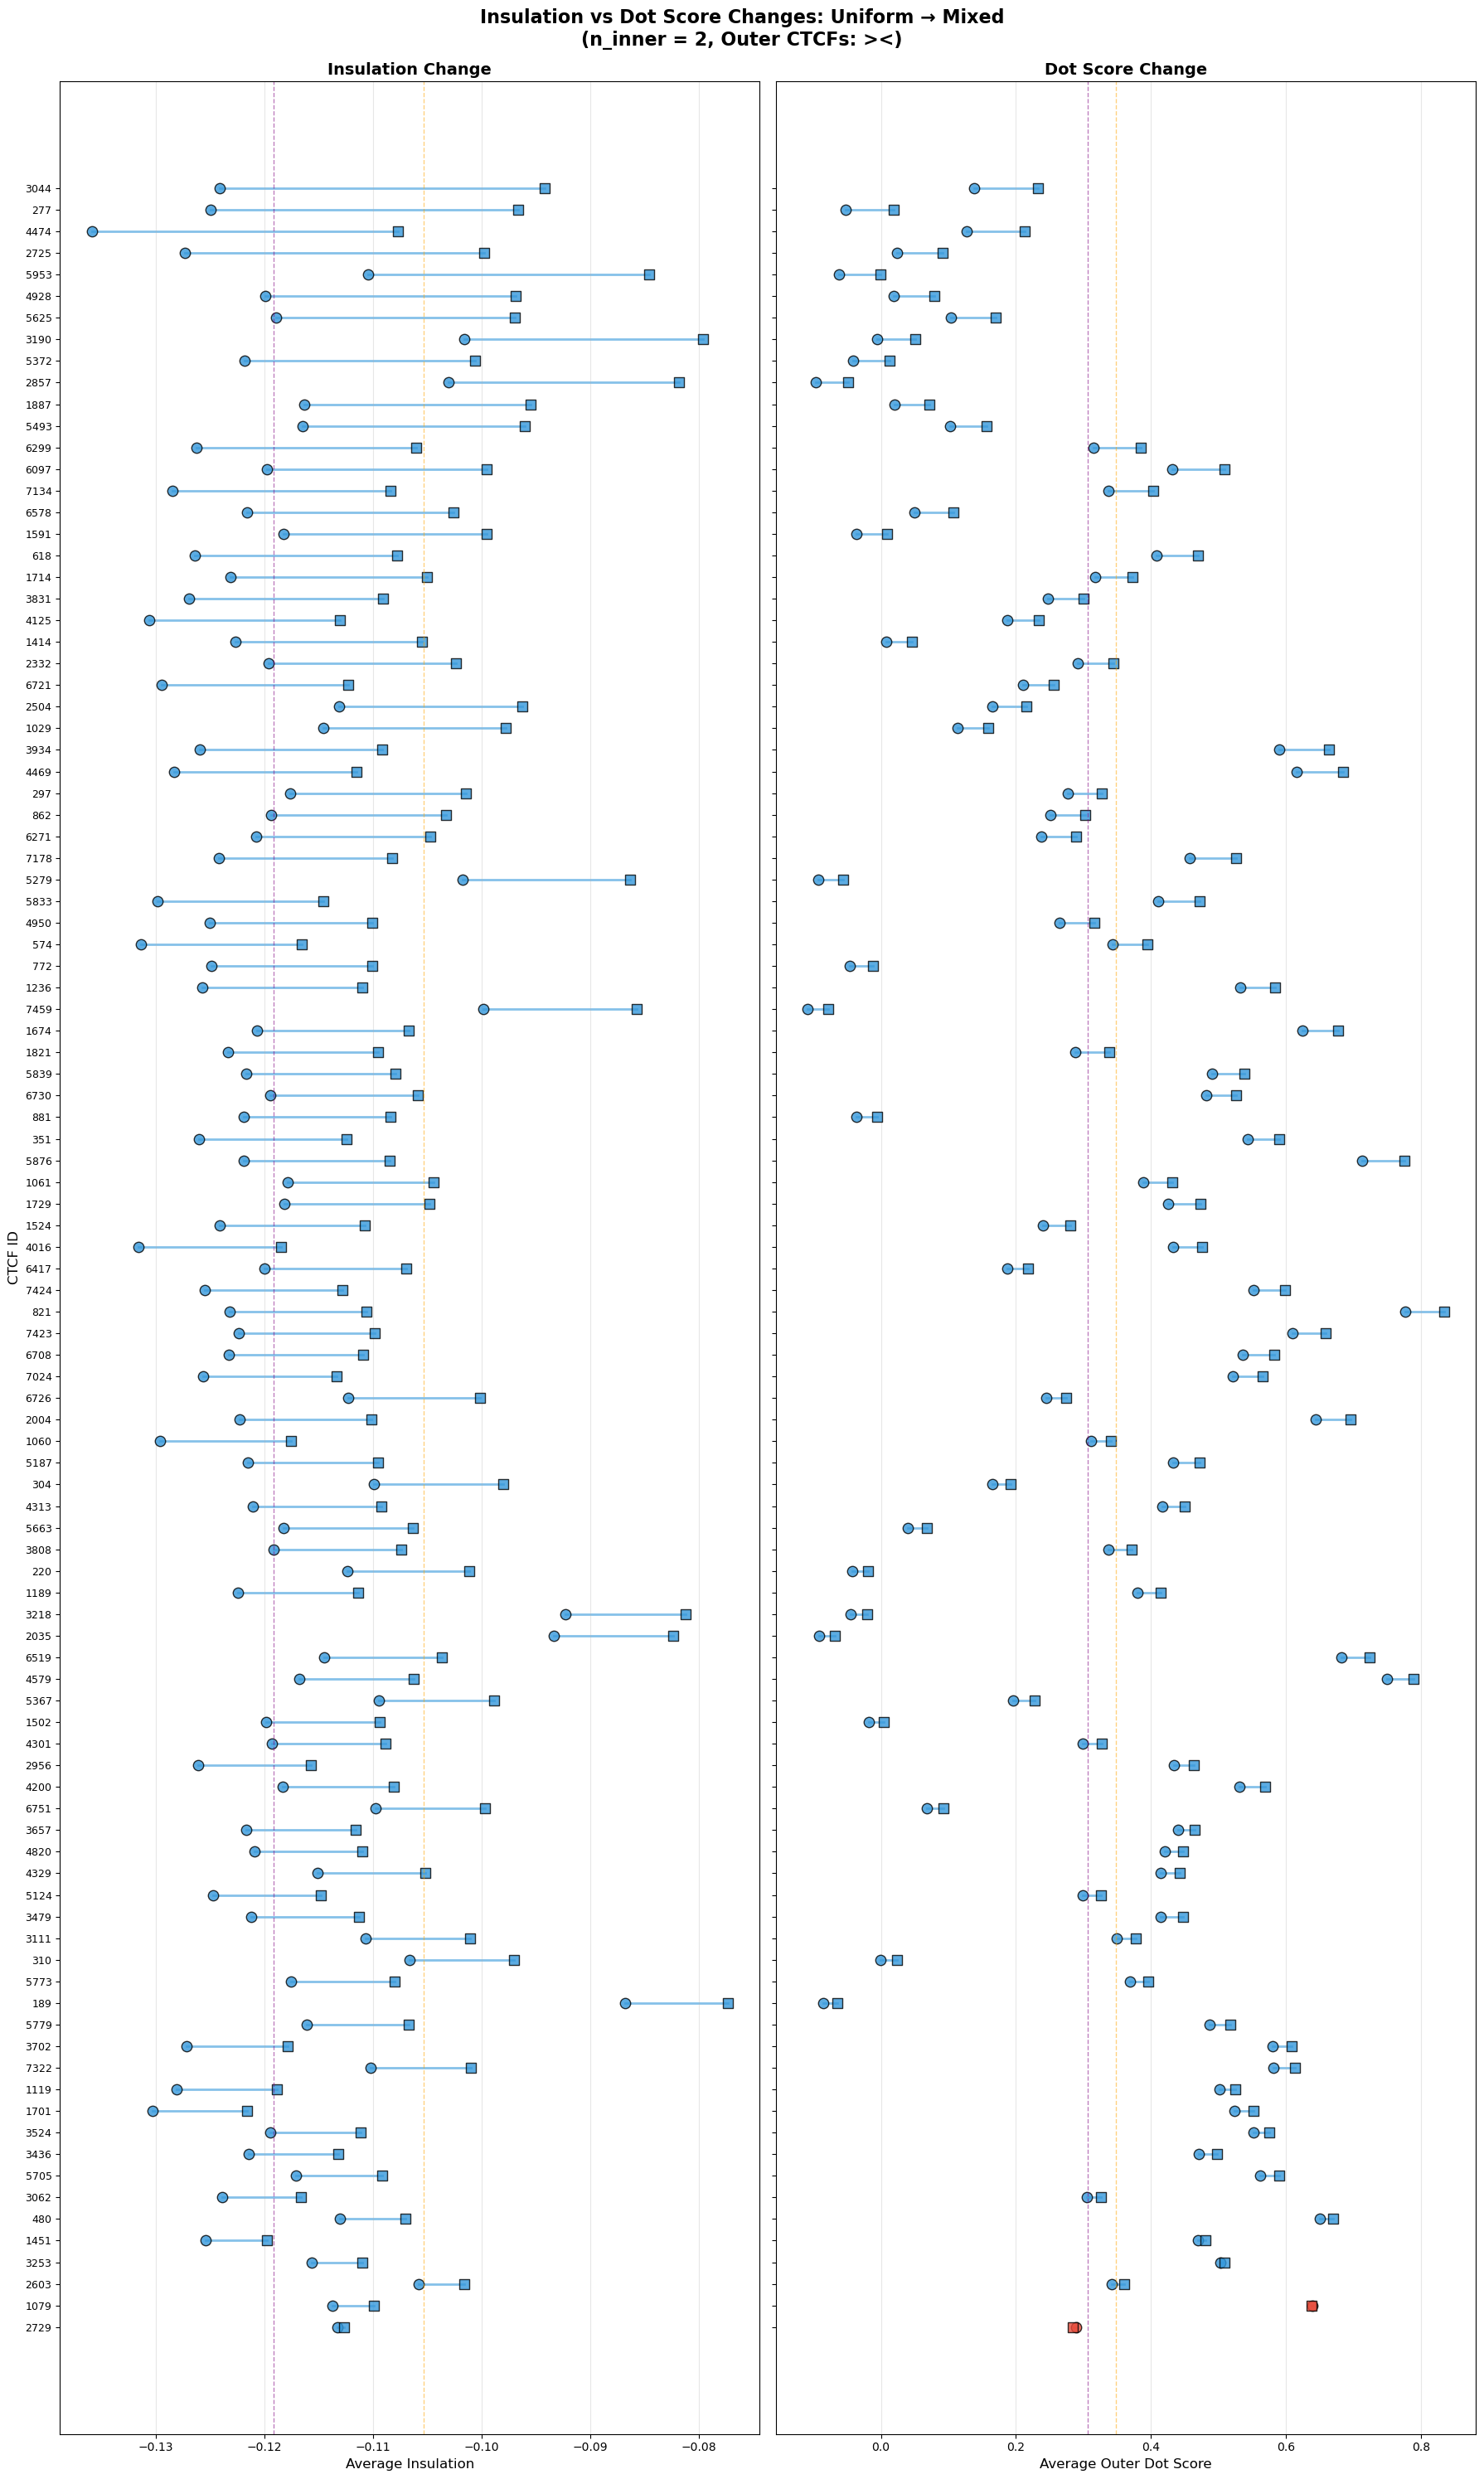

In [42]:
fig, axes, data = create_dual_metric_comparison(df, n_inner_ctcfs=2,
                                                save_path='insulation_vs_dot.png')
plt.show()

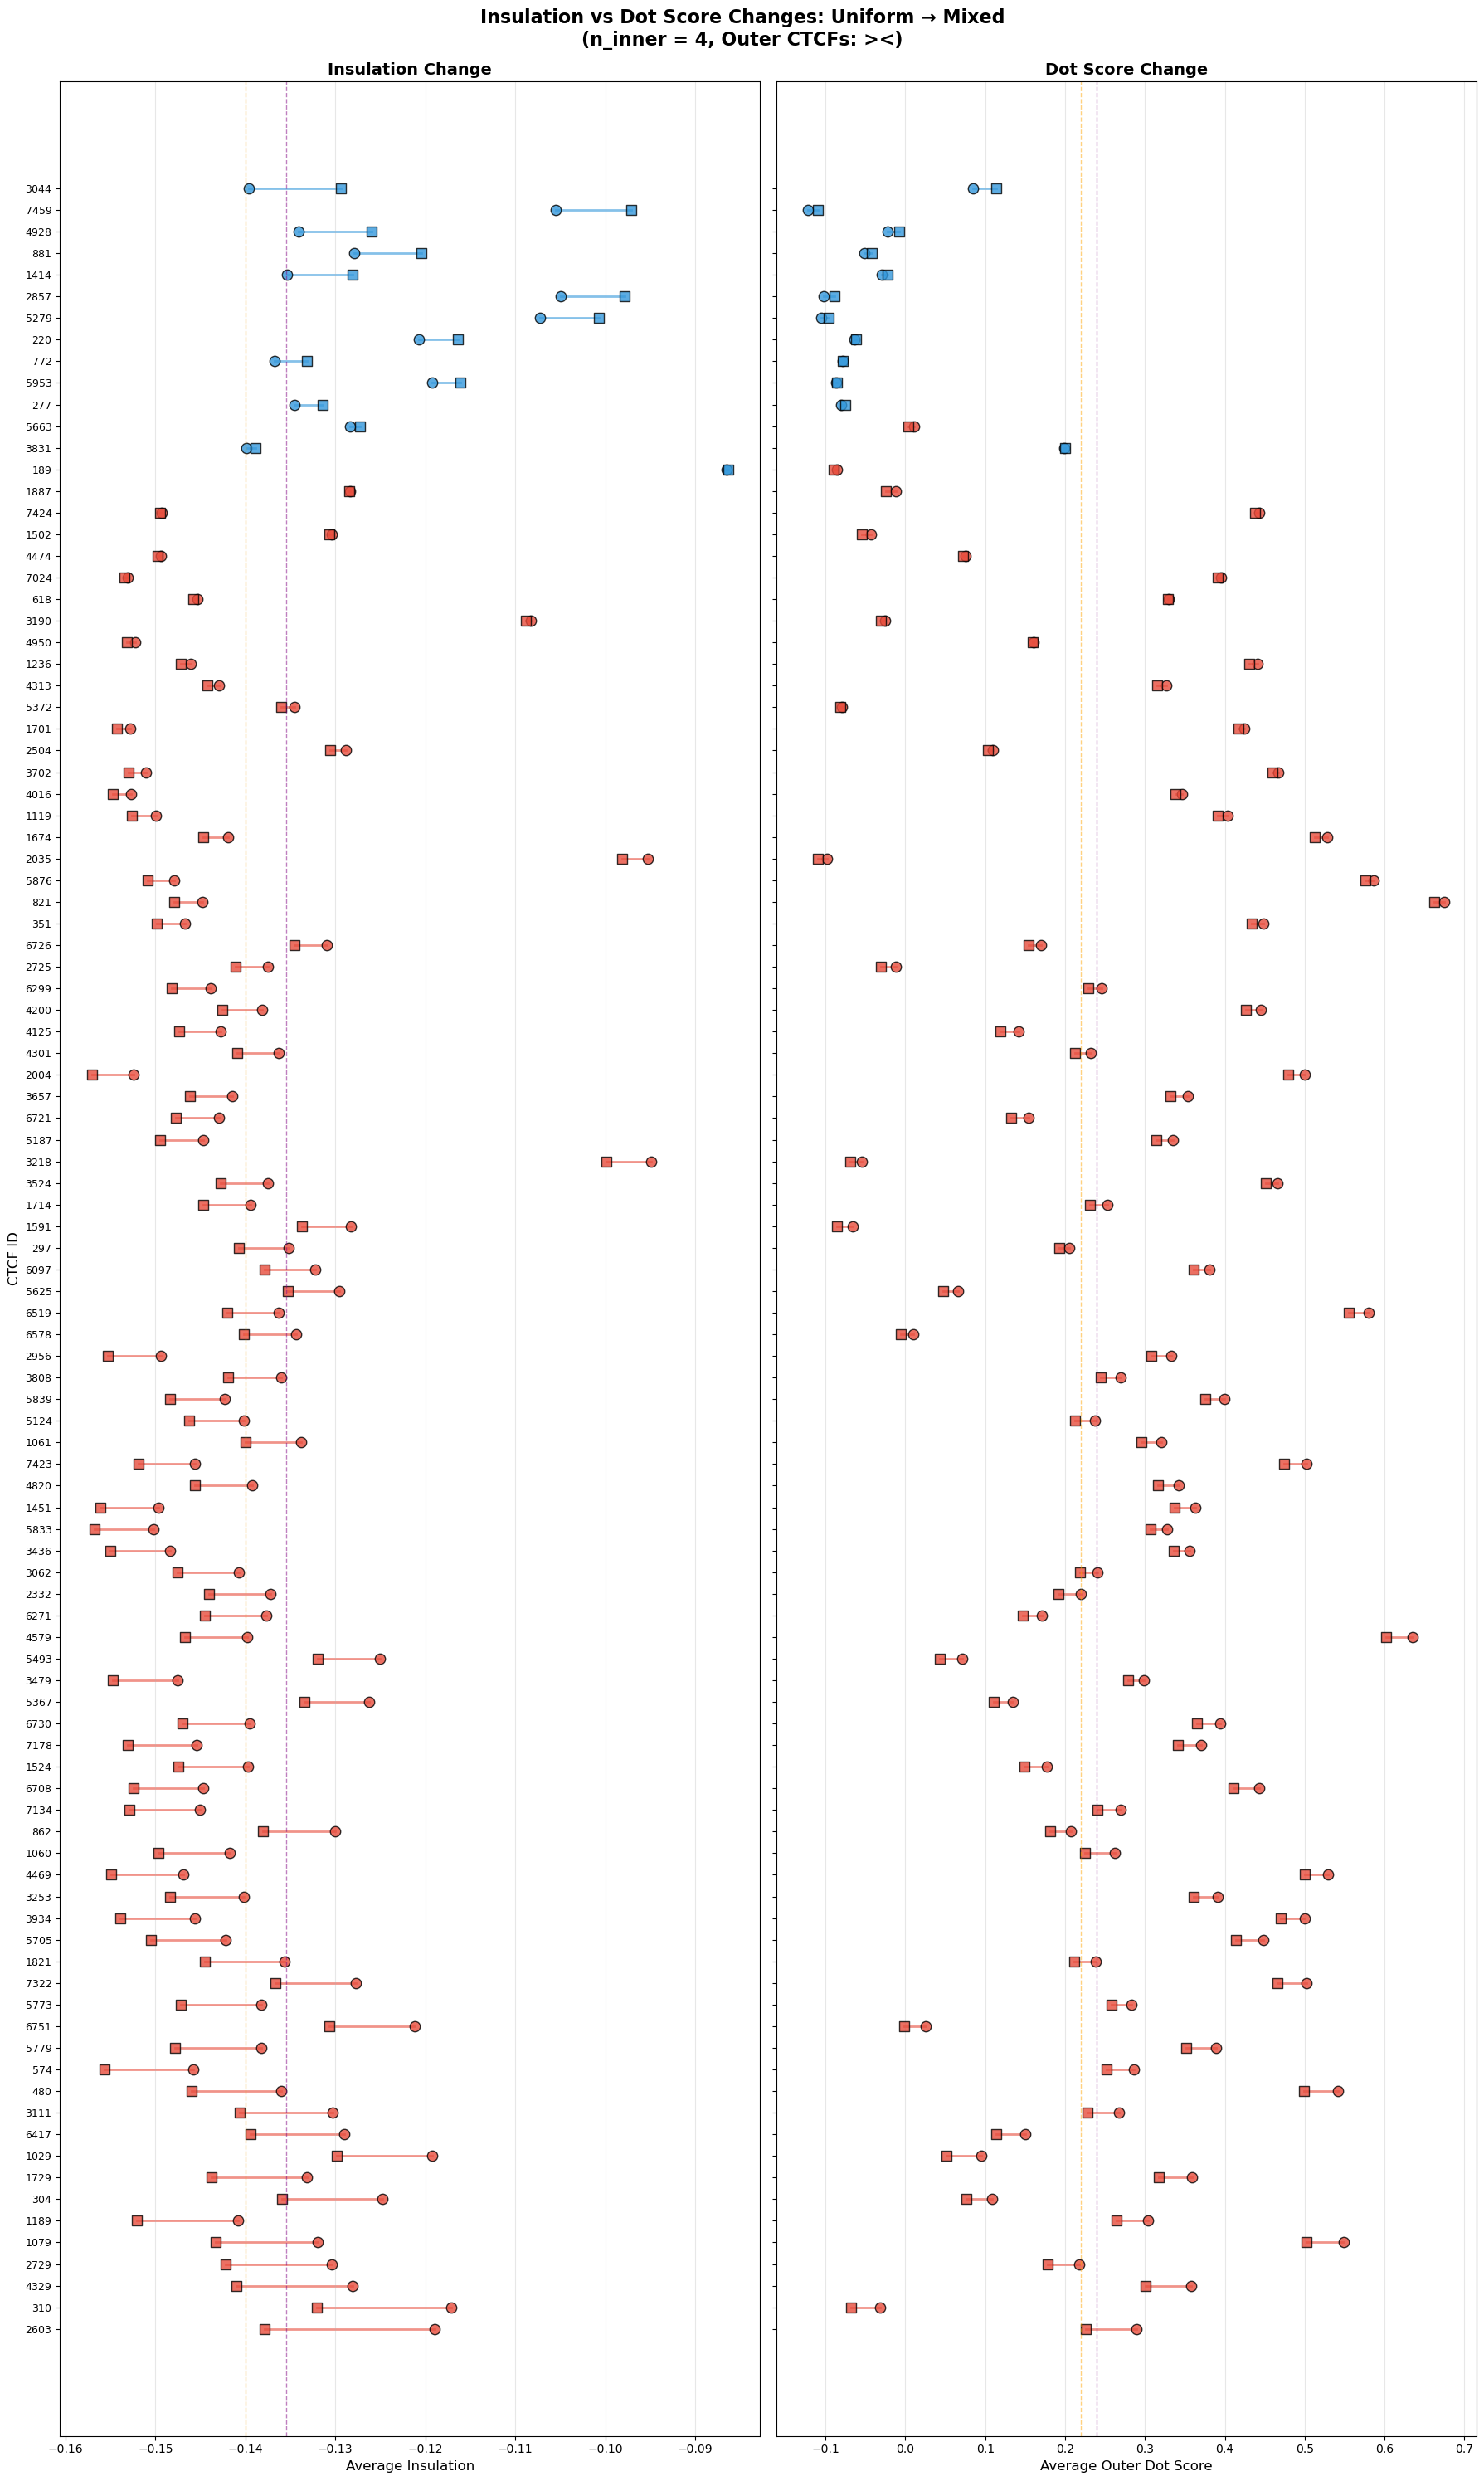

In [43]:
fig, axes, data = create_dual_metric_comparison(df, n_inner_ctcfs=4,
                                                save_path='insulation_vs_dot.png')
plt.show()

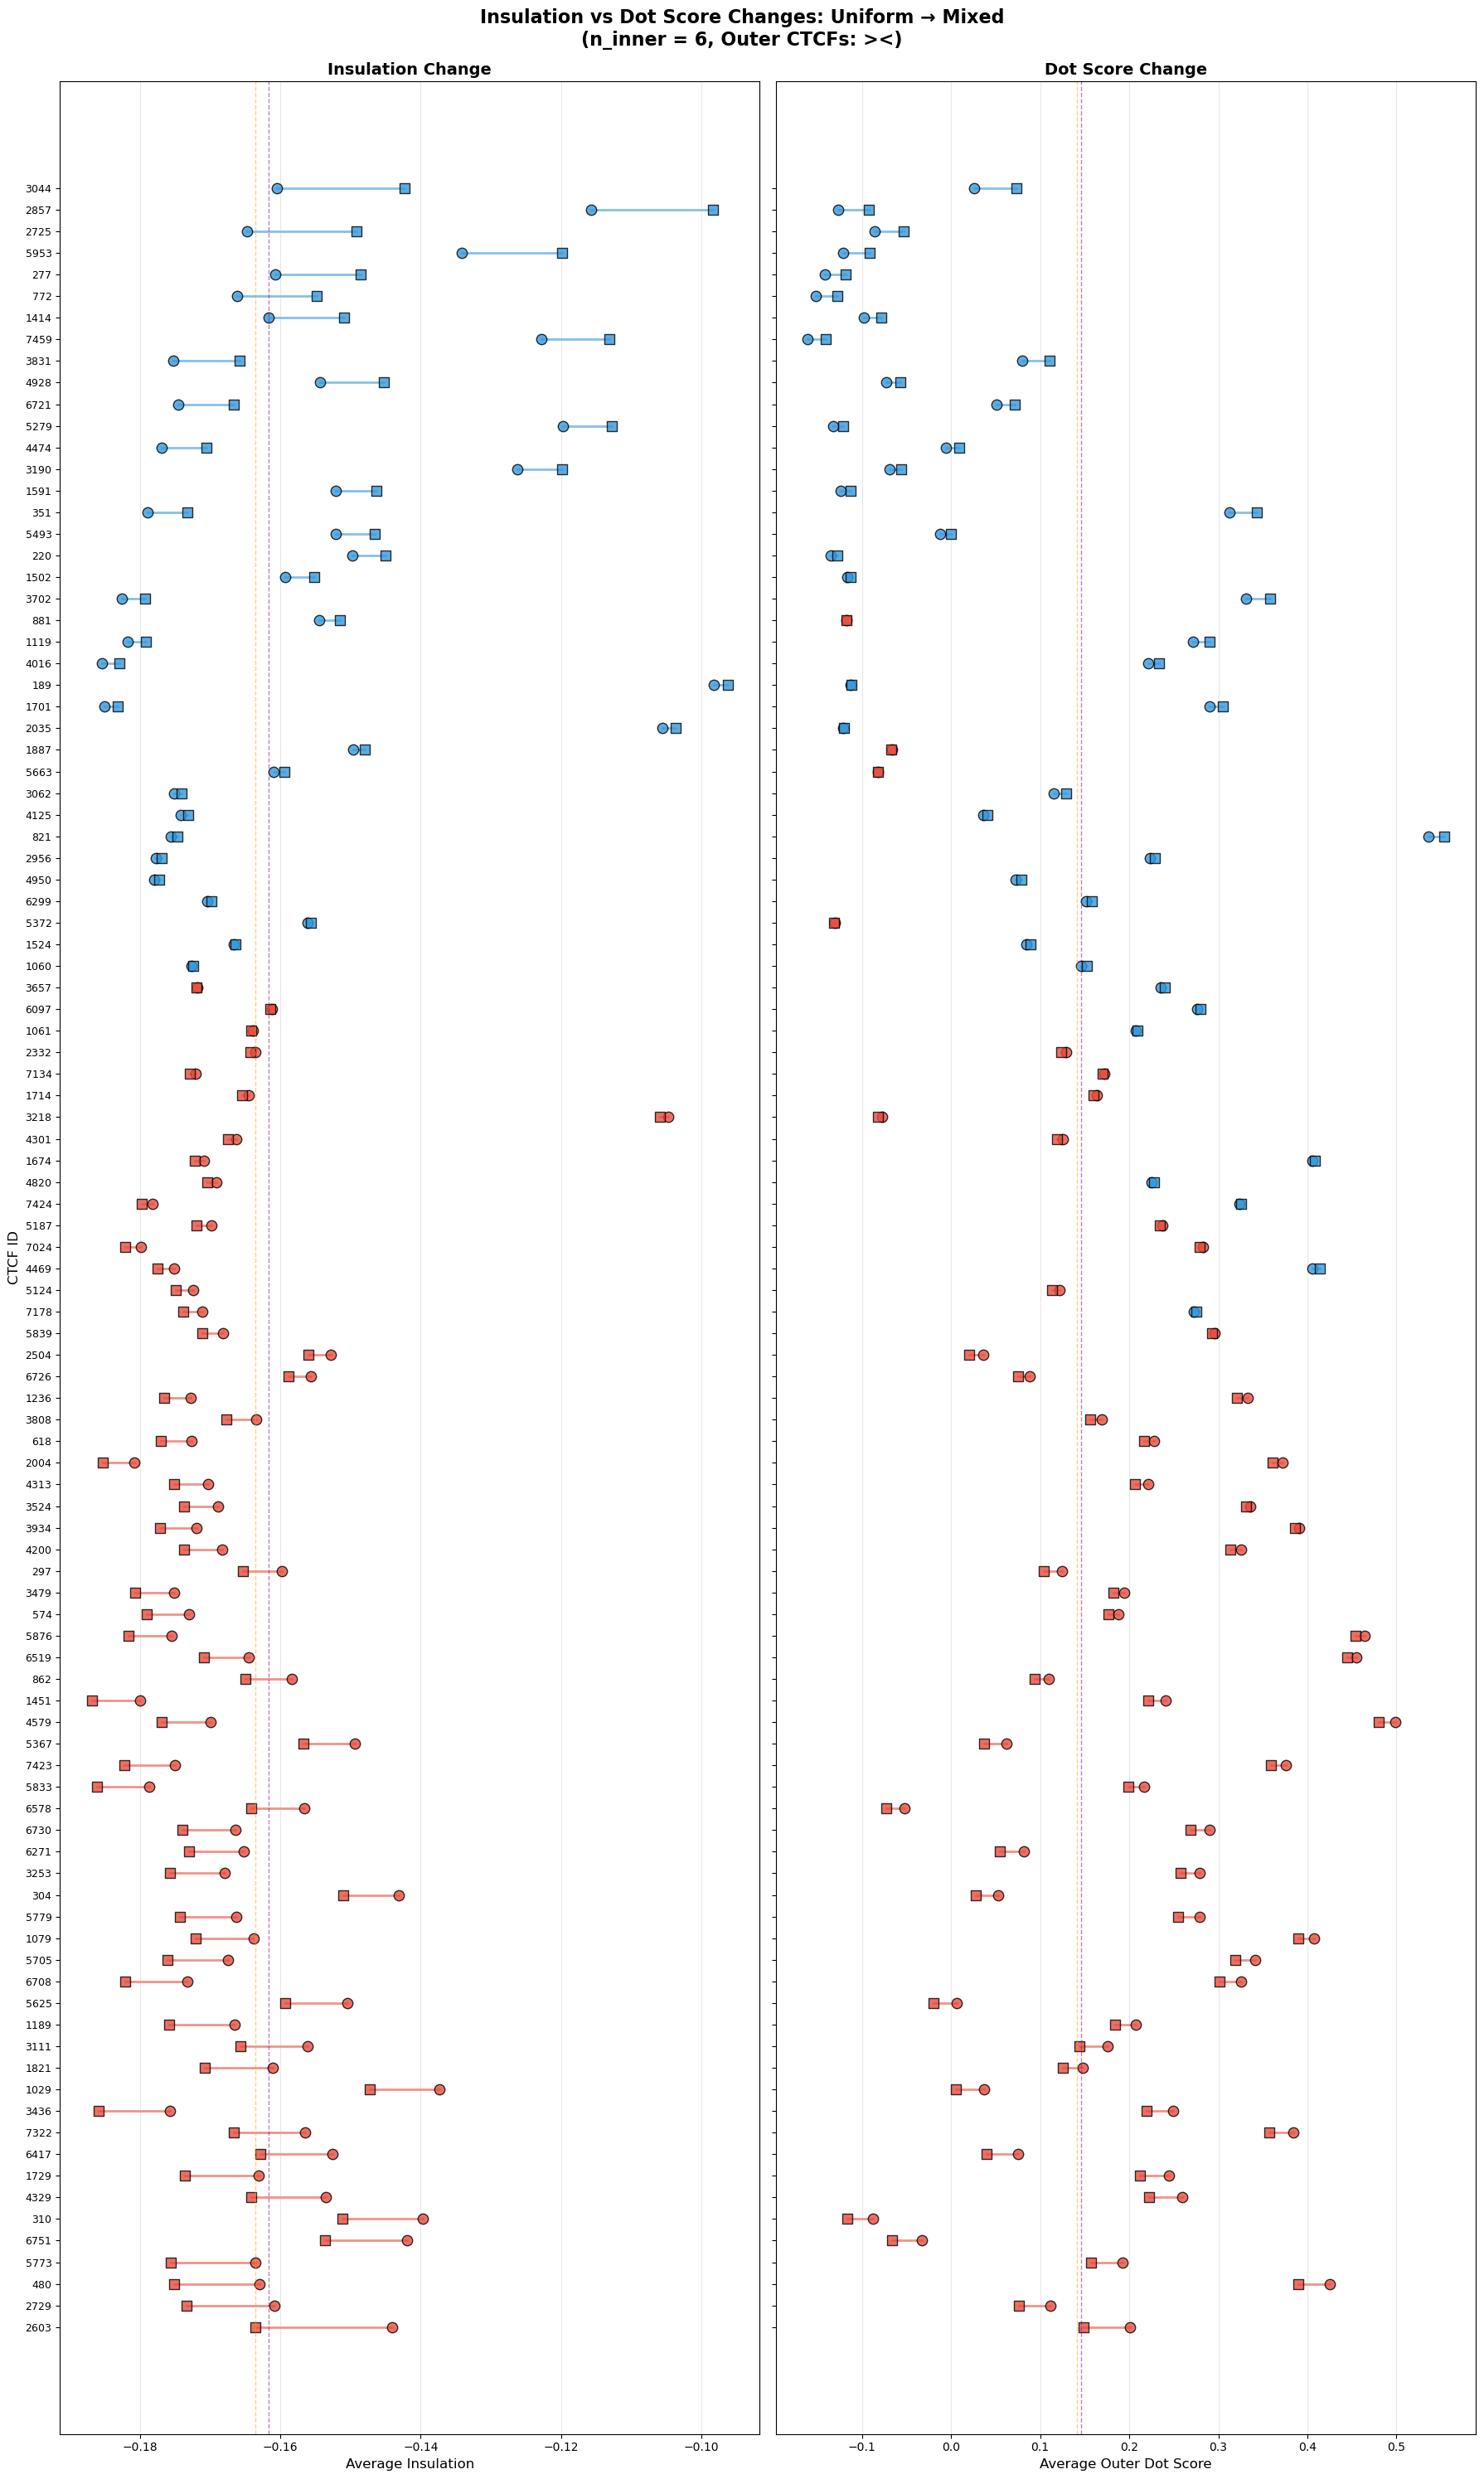

In [44]:
fig, axes, data = create_dual_metric_comparison(df, n_inner_ctcfs=6,
                                                save_path='insulation_vs_dot.png')
plt.show()

In [46]:
from scipy import stats

✓ Saved: correlation.png

HYPOTHESIS TEST: Increased Insulation → Stronger Dots

Correlation coefficient: r = 0.872
P-value: 3.99e-32
✓ HYPOTHESIS SUPPORTED: Significant positive correlation
  Sites with increased insulation tend to have stronger dots

Quadrant distribution:
  Q1 (Both ↑):      98 (98.0%)
  Q2 (Ins↓ Dot↑):    0 (0.0%)
  Q3 (Both ↓):       0 (0.0%)
  Q4 (Ins↑ Dot↓):    2 (2.0%)


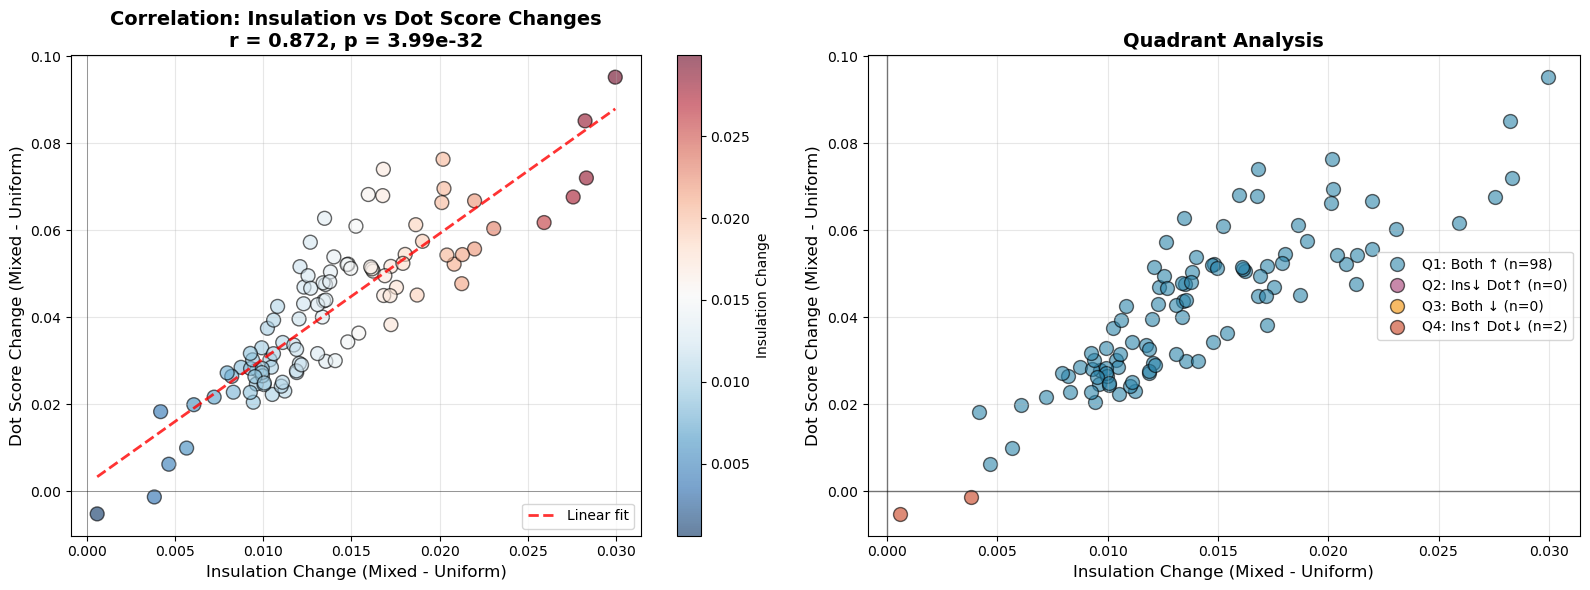

In [47]:
fig, axes, data = create_correlation_plot(df, n_inner_ctcfs=2,
                                         save_path='correlation.png')
plt.show()

✓ Saved: correlation.png

HYPOTHESIS TEST: Increased Insulation → Stronger Dots

Correlation coefficient: r = 0.959
P-value: 1.62e-55
✓ HYPOTHESIS SUPPORTED: Significant positive correlation
  Sites with increased insulation tend to have stronger dots

Quadrant distribution:
  Q1 (Both ↑):      12 (12.0%)
  Q2 (Ins↓ Dot↑):    0 (0.0%)
  Q3 (Both ↓):      86 (86.0%)
  Q4 (Ins↑ Dot↓):    2 (2.0%)


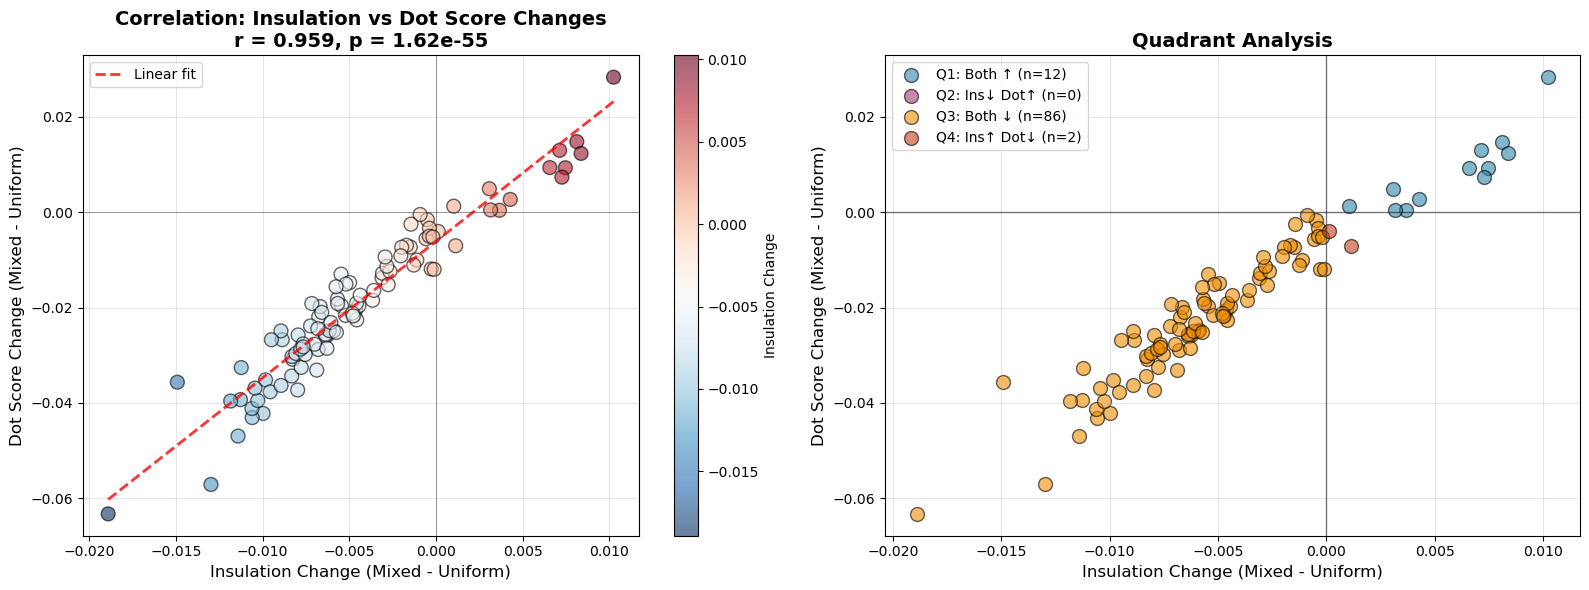

In [48]:
fig, axes, data = create_correlation_plot(df, n_inner_ctcfs=4,
                                         save_path='correlation.png')
plt.show()

✓ Saved: correlation.png

HYPOTHESIS TEST: Increased Insulation → Stronger Dots

Correlation coefficient: r = 0.951
P-value: 5.89e-52
✓ HYPOTHESIS SUPPORTED: Significant positive correlation
  Sites with increased insulation tend to have stronger dots

Quadrant distribution:
  Q1 (Both ↑):      33 (33.0%)
  Q2 (Ins↓ Dot↑):    8 (8.0%)
  Q3 (Both ↓):      55 (55.0%)
  Q4 (Ins↑ Dot↓):    4 (4.0%)


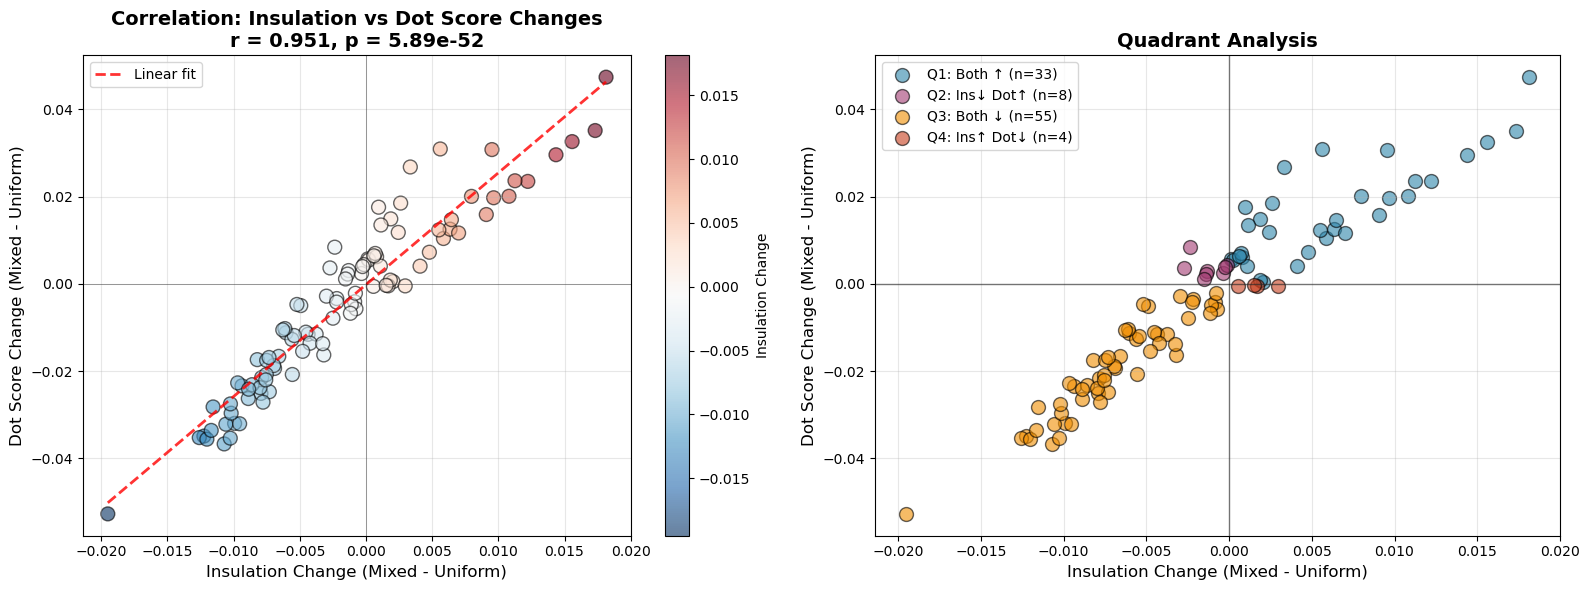

In [49]:
fig, axes, data = create_correlation_plot(df, n_inner_ctcfs=6,
                                         save_path='correlation.png')
plt.show()

In [50]:
def verify_insulation_increase_ctcfs(df, n_inner_ctcfs=2):
    """
    Verify that CTCFs with increased insulation also have increased dot scores
    
    Parameters:
    -----------
    df : pd.DataFrame
        Results dataframe for >< outer configuration
    n_inner_ctcfs : int
        Number of inner CTCFs to analyze
    
    Returns:
    --------
    pd.DataFrame : Detailed verification results
    """
    print("="*80)
    print("VERIFICATION: CTCFs with Increased Insulation")
    print("="*80)
    print(f"\nAnalyzing {n_inner_ctcfs} inner CTCFs")
    
    # Filter for specific number of inner CTCFs
    df_subset = df[df['num_middle_ctcfs'] == n_inner_ctcfs].copy()
    
    # Classify orientations
    df_subset['orientation_type'] = df_subset['ctcf_orientations'].apply(
        classify_inner_orientation
    )
    
    # Keep only uniform and mixed
    df_subset = df_subset[df_subset['orientation_type'].isin(['uniform', 'mixed'])].copy()
    
    print(f"\nTotal experiments: {len(df_subset)}")
    print(f"  Uniform: {(df_subset['orientation_type'] == 'uniform').sum()}")
    print(f"  Mixed:   {(df_subset['orientation_type'] == 'mixed').sum()}")
    
    # Calculate averages for each CTCF × orientation (averaged over 10 backgrounds)
    summary_insulation = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_insulation'].mean().reset_index()
    summary_dot = df_subset.groupby(['ctcf_id', 'orientation_type'])['avg_outer_dot_score'].mean().reset_index()
    
    # Pivot for insulation
    pivot_insulation = summary_insulation.pivot(
        index='ctcf_id', 
        columns='orientation_type', 
        values='avg_insulation'
    )
    pivot_insulation['insulation_change'] = pivot_insulation['mixed'] - pivot_insulation['uniform']
    pivot_insulation = pivot_insulation.rename(columns={
        'uniform': 'insulation_uniform',
        'mixed': 'insulation_mixed'
    })
    
    # Pivot for dot score
    pivot_dot = summary_dot.pivot(
        index='ctcf_id',
        columns='orientation_type',
        values='avg_outer_dot_score'
    )
    pivot_dot['dot_change'] = pivot_dot['mixed'] - pivot_dot['uniform']
    pivot_dot = pivot_dot.rename(columns={
        'uniform': 'dot_uniform',
        'mixed': 'dot_mixed'
    })
    
    # Merge
    result = pd.merge(
        pivot_insulation,
        pivot_dot,
        left_index=True,
        right_index=True
    )
    
    result = result.reset_index()
    
    # Find CTCFs with increased insulation
    increased_insulation = result[result['insulation_change'] > 0].copy()
    
    print(f"\n{'='*80}")
    print(f"CTCFs with INCREASED Insulation (Mixed > Uniform)")
    print(f"{'='*80}")
    print(f"Count: {len(increased_insulation)}")
    
    if len(increased_insulation) == 0:
        print("No CTCFs found with increased insulation.")
        return result
    
    # Check if dot scores also increased
    increased_insulation['dot_also_increased'] = increased_insulation['dot_change'] > 0
    
    n_both_increase = increased_insulation['dot_also_increased'].sum()
    n_dot_decrease = (~increased_insulation['dot_also_increased']).sum()
    
    print(f"\nOf these {len(increased_insulation)} CTCFs:")
    print(f"  Dot score ALSO increased: {n_both_increase} ({n_both_increase/len(increased_insulation)*100:.1f}%)")
    print(f"  Dot score decreased:      {n_dot_decrease} ({n_dot_decrease/len(increased_insulation)*100:.1f}%)")
    
    # Detailed table
    print(f"\n{'='*80}")
    print("DETAILED VERIFICATION TABLE")
    print(f"{'='*80}")
    
    display_cols = [
        'ctcf_id',
        'insulation_uniform', 'insulation_mixed', 'insulation_change',
        'dot_uniform', 'dot_mixed', 'dot_change',
        'dot_also_increased'
    ]
    
    increased_insulation_sorted = increased_insulation.sort_values('insulation_change', ascending=False)
    
    print("\nCTCFs with Increased Insulation:")
    print(increased_insulation_sorted[display_cols].to_string(index=False))
    
    # Summary statistics
    print(f"\n{'='*80}")
    print("SUMMARY STATISTICS")
    print(f"{'='*80}")
    
    print(f"\nInsulation changes:")
    print(f"  Mean:   {increased_insulation['insulation_change'].mean():.6f}")
    print(f"  Median: {increased_insulation['insulation_change'].median():.6f}")
    print(f"  Min:    {increased_insulation['insulation_change'].min():.6f}")
    print(f"  Max:    {increased_insulation['insulation_change'].max():.6f}")
    print(f"  Std:    {increased_insulation['insulation_change'].std():.6f}")
    
    print(f"\nDot score changes:")
    print(f"  Mean:   {increased_insulation['dot_change'].mean():.6f}")
    print(f"  Median: {increased_insulation['dot_change'].median():.6f}")
    print(f"  Min:    {increased_insulation['dot_change'].min():.6f}")
    print(f"  Max:    {increased_insulation['dot_change'].max():.6f}")
    print(f"  Std:    {increased_insulation['dot_change'].std():.6f}")
    
    # Check for exceptions
    if n_dot_decrease > 0:
        print(f"\n{'='*80}")
        print("⚠️  EXCEPTIONS: Insulation ↑ but Dot ↓")
        print(f"{'='*80}")
        
        exceptions = increased_insulation[~increased_insulation['dot_also_increased']]
        print(exceptions[display_cols].to_string(index=False))
        
        print(f"\nException CTCFs: {exceptions['ctcf_id'].tolist()}")
    else:
        print(f"\n{'='*80}")
        print("✓ VERIFICATION PASSED!")
        print(f"{'='*80}")
        print(f"\nAll {len(increased_insulation)} CTCFs with increased insulation")
        print("also show increased dot scores.")
        print("\n100% consistency! ✓")
    
    # Statistical test
    from scipy import stats
    
    print(f"\n{'='*80}")
    print("STATISTICAL TEST")
    print(f"{'='*80}")
    
    # Paired t-test for insulation
    t_ins, p_ins = stats.ttest_rel(
        increased_insulation['insulation_uniform'],
        increased_insulation['insulation_mixed']
    )
    
    print(f"\nInsulation (Uniform vs Mixed):")
    print(f"  Paired t-test: t = {t_ins:.3f}, p = {p_ins:.2e}")
    print(f"  Mean difference: {increased_insulation['insulation_change'].mean():.6f}")
    
    # Paired t-test for dot score
    t_dot, p_dot = stats.ttest_rel(
        increased_insulation['dot_uniform'],
        increased_insulation['dot_mixed']
    )
    
    print(f"\nDot Score (Uniform vs Mixed):")
    print(f"  Paired t-test: t = {t_dot:.3f}, p = {p_dot:.2e}")
    print(f"  Mean difference: {increased_insulation['dot_change'].mean():.6f}")
    
    # Correlation within this subset
    corr, p_corr = stats.pearsonr(
        increased_insulation['insulation_change'],
        increased_insulation['dot_change']
    )
    
    print(f"\nCorrelation (Insulation change vs Dot change):")
    print(f"  Pearson r = {corr:.3f}, p = {p_corr:.2e}")
    
    return result, increased_insulation


In [51]:
def create_verification_plot(df, n_inner_ctcfs=2, save_path='verification_plot.png'):
    """
    Create plot specifically showing the CTCFs with increased insulation
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get data
    _, increased_insulation = verify_insulation_increase_ctcfs(df, n_inner_ctcfs)
    
    if len(increased_insulation) == 0:
        print("No CTCFs with increased insulation to plot.")
        return None, None
    
    # Create figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # Panel 1: Insulation changes
    ax = axes[0, 0]
    ctcf_ids = increased_insulation['ctcf_id'].values
    y_pos = np.arange(len(ctcf_ids))
    
    ax.barh(y_pos, increased_insulation['insulation_change'].values, 
            color='#3498DB', alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ctcf_ids, fontsize=9)
    ax.set_xlabel('Insulation Change (Mixed - Uniform)', fontsize=11)
    ax.set_ylabel('CTCF ID', fontsize=11)
    ax.set_title('Insulation Increase', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    # Panel 2: Dot score changes
    ax = axes[0, 1]
    colors = ['#2ECC71' if x else '#E74C3C' 
              for x in increased_insulation['dot_also_increased']]
    
    ax.barh(y_pos, increased_insulation['dot_change'].values, 
            color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ctcf_ids, fontsize=9)
    ax.set_xlabel('Dot Score Change (Mixed - Uniform)', fontsize=11)
    ax.set_title('Dot Score Change', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    
    # Panel 3: Correlation
    ax = axes[1, 0]
    from scipy import stats
    
    corr, p_value = stats.pearsonr(
        increased_insulation['insulation_change'],
        increased_insulation['dot_change']
    )
    
    ax.scatter(increased_insulation['insulation_change'],
               increased_insulation['dot_change'],
               s=100, alpha=0.6, color='#9B59B6', edgecolors='black', linewidths=1)
    
    # Add regression line
    z = np.polyfit(increased_insulation['insulation_change'], 
                   increased_insulation['dot_change'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(increased_insulation['insulation_change'].min(),
                        increased_insulation['insulation_change'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8)
    
    ax.set_xlabel('Insulation Change', fontsize=11)
    ax.set_ylabel('Dot Score Change', fontsize=11)
    ax.set_title(f'Correlation: r = {corr:.3f}, p = {p_value:.2e}', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Panel 4: Summary bars
    ax = axes[1, 1]
    
    categories = ['Insulation\nUniform', 'Insulation\nMixed', 
                 'Dot Score\nUniform', 'Dot Score\nMixed']
    values = [
        increased_insulation['insulation_uniform'].mean(),
        increased_insulation['insulation_mixed'].mean(),
        increased_insulation['dot_uniform'].mean(),
        increased_insulation['dot_mixed'].mean()
    ]
    colors_bar = ['#E8F4F8', '#3498DB', '#F8E8E8', '#E74C3C']
    
    bars = ax.bar(categories, values, color=colors_bar, alpha=0.7, 
                  edgecolor='black', linewidth=2)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.4f}',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Average Value', fontsize=11)
    ax.set_title('Mean Values: Uniform vs Mixed', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Overall title
    fig.suptitle(f'Verification: {len(increased_insulation)} CTCFs with Increased Insulation\n'
                 f'(n_inner = {n_inner_ctcfs}, Outer CTCFs: ><)',
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"\n✓ Saved: {save_path}")
    plt.show()
    
    return fig, axes


In [52]:
all_data, increased_ctcfs = verify_insulation_increase_ctcfs(df, n_inner_ctcfs=2)

VERIFICATION: CTCFs with Increased Insulation

Analyzing 2 inner CTCFs

Total experiments: 2000
  Uniform: 1000
  Mixed:   1000

CTCFs with INCREASED Insulation (Mixed > Uniform)
Count: 100

Of these 100 CTCFs:
  Dot score ALSO increased: 98 (98.0%)
  Dot score decreased:      2 (2.0%)

DETAILED VERIFICATION TABLE

CTCFs with Increased Insulation:
 ctcf_id  insulation_uniform  insulation_mixed  insulation_change  dot_uniform  dot_mixed  dot_change  dot_also_increased
    3044           -0.124103         -0.094157           0.029946     0.137844   0.232999    0.095155                True
     277           -0.124946         -0.096636           0.028310    -0.052446   0.019551    0.071996                True
    4474           -0.135907         -0.107673           0.028234     0.127371   0.212489    0.085118                True
    2725           -0.127314         -0.099753           0.027561     0.024092   0.091714    0.067622                True
    5953           -0.110469         -0.

VERIFICATION: CTCFs with Increased Insulation

Analyzing 2 inner CTCFs

Total experiments: 2000
  Uniform: 1000
  Mixed:   1000

CTCFs with INCREASED Insulation (Mixed > Uniform)
Count: 100

Of these 100 CTCFs:
  Dot score ALSO increased: 98 (98.0%)
  Dot score decreased:      2 (2.0%)

DETAILED VERIFICATION TABLE

CTCFs with Increased Insulation:
 ctcf_id  insulation_uniform  insulation_mixed  insulation_change  dot_uniform  dot_mixed  dot_change  dot_also_increased
    3044           -0.124103         -0.094157           0.029946     0.137844   0.232999    0.095155                True
     277           -0.124946         -0.096636           0.028310    -0.052446   0.019551    0.071996                True
    4474           -0.135907         -0.107673           0.028234     0.127371   0.212489    0.085118                True
    2725           -0.127314         -0.099753           0.027561     0.024092   0.091714    0.067622                True
    5953           -0.110469         -0.

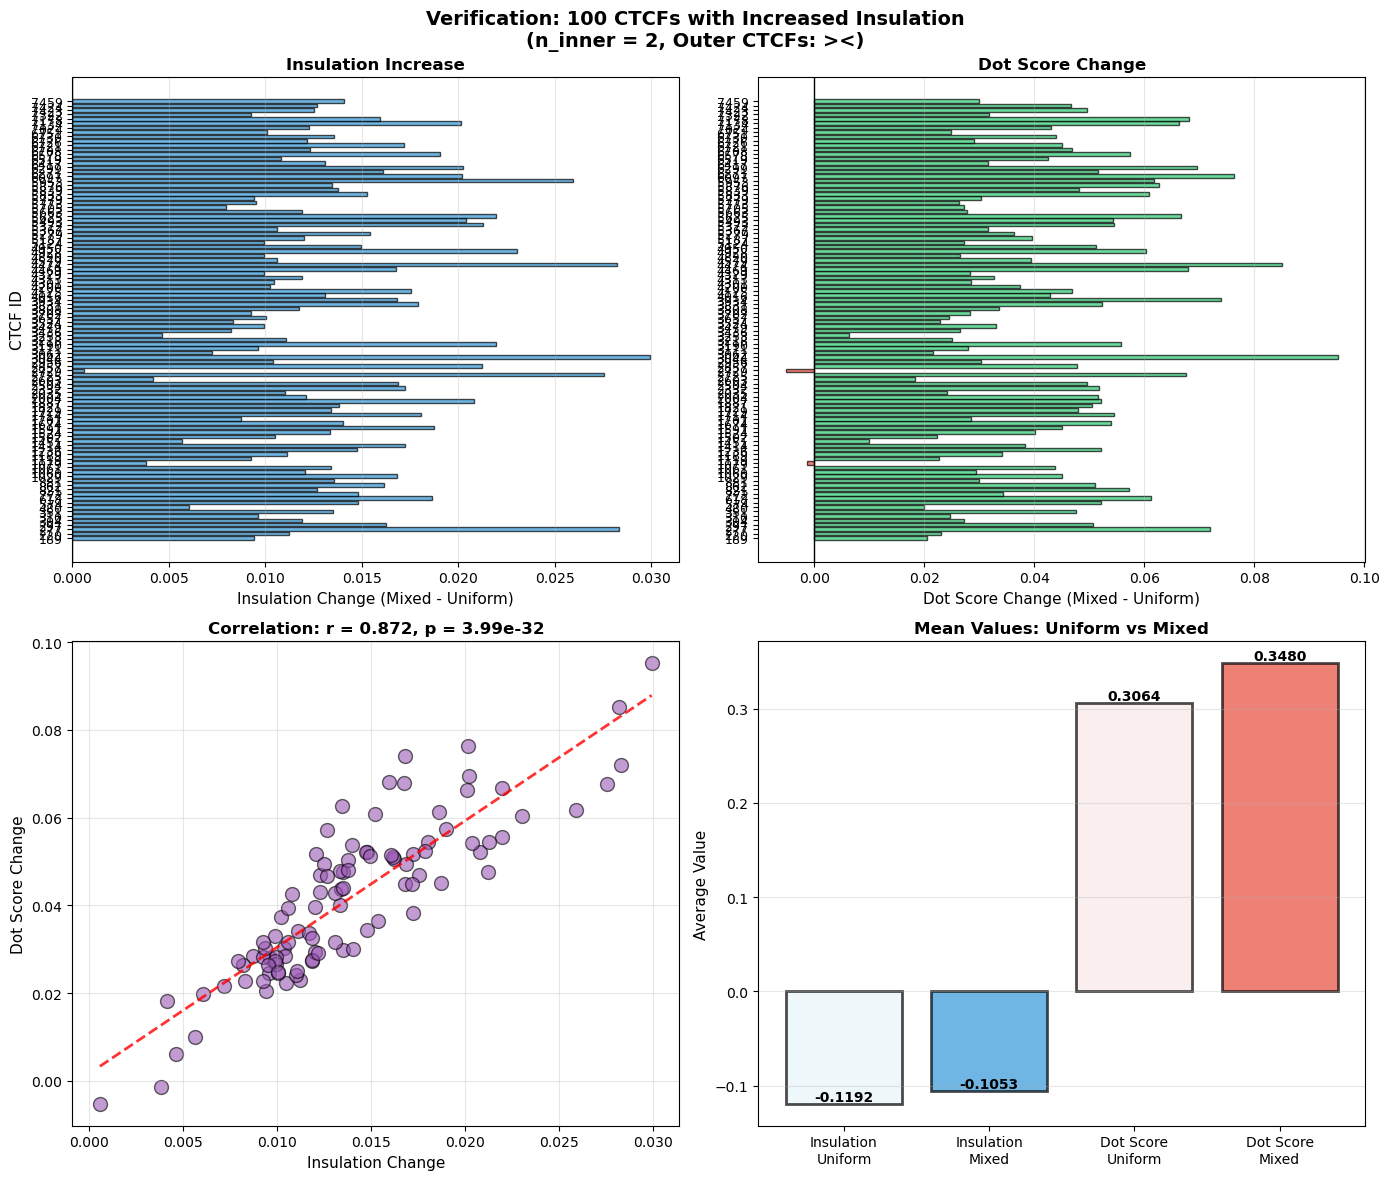

In [53]:
fig, axes = create_verification_plot(df, n_inner_ctcfs=2,
                                     save_path='verification.png')